# Crude Oil Assay Analysis — Comparative Study

This notebook performs a comprehensive comparative analysis of five crude oil assays sourced from ExxonMobil's EMTEC assay database. The analysis covers:

1. **Whole Crude Properties** – API gravity, density, sulfur, TAN, metals, viscosity, RVP  
2. **Yield Distribution** – Cut yields (%wt, %vol) and TBP distillation curves  
3. **Cut Properties Profiles** – How key properties vary across the distillation curve  
4. **Naphtha Quality** – RON, MON, PNA composition for light end fractions  
5. **Middle Distillate Quality** – Cetane Index, Freeze Point, Smoke Point, Naphthalenes  
6. **Vacuum Gas Oil & Residue** – MCR, Asphaltenes, Vanadium, Nickel  
7. **Molecular Composition** – Light hydrocarbon molecule breakdown  
8. **Key Inferences & Rankings** – Comparative conclusions and crude suitability assessment

### Imports & Global Configuration

In [31]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import seaborn as sns
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D
from textwrap import wrap
from IPython.display import display, HTML

warnings.filterwarnings('ignore')

# Plot style
plt.rcParams.update({
    'figure.dpi': 130,
    'figure.facecolor': 'white',
    'axes.facecolor': '#F8F9FA',
    'axes.grid': True,
    'grid.color': '#DDDDDD',
    'grid.linestyle': '--',
    'grid.linewidth': 0.6,
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 12,
    'axes.labelsize': 10,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
})

# Crude colour palette
CRUDE_COLORS = {
    'Azeri Light': '#1565C0',   # deep blue
    'Erha':        '#2E7D32',   # dark green
    'Tapis':       '#E65100',   # burnt orange
    'Upper Zakum': '#6A1B9A',   # purple
    'WTI Light':   '#B71C1C',   # dark red
}
CRUDE_NAMES = list(CRUDE_COLORS.keys())
PALETTE     = list(CRUDE_COLORS.values())

# File paths
BASE = r'd:\github\Distillation-column-agent\Assay data'
ASSAY_FILES = {
    'Azeri Light': os.path.join(BASE, 'Azeri Light',  'Azeri_Light.xlsx'),
    'Erha':        os.path.join(BASE, 'Erha',         'Erha.xlsx'),
    'Tapis':       os.path.join(BASE, 'Tapis',        'Tapis.xlsx'),
    'Upper Zakum': os.path.join(BASE, 'Upper_Zakum',  'Upper_Zakum (1).xlsx'),
    'WTI Light':   os.path.join(BASE, 'WTI_Light',    'WTI_Light.xlsx'),
}

# Friendly cut labels
CUT_FRIENDLY = {
    'C5-65.0':   'Light Ends\n(C5–65°C)',
    'C5-65':     'Light Ends\n(C5–65°C)',
    '65.0-100.0':'Light Naphtha\n(65–100°C)',
    '65-100':    'Light Naphtha\n(65–100°C)',
    '100.0-150.0':'Hvy Naphtha\n(100–150°C)',
    '100-150':   'Hvy Naphtha\n(100–150°C)',
    '150.0-200.0':'Kerosene\n(150–200°C)',
    '150-200':   'Kerosene\n(150–200°C)',
    '200.0-250.0':'Jet Fuel\n(200–250°C)',
    '200-250':   'Jet Fuel\n(200–250°C)',
    '250.0-300.0':'Diesel\n(250–300°C)',
    '250-300':   'Diesel\n(250–300°C)',
    '300.0-350.0':'Lt AGO\n(300–350°C)',
    '300-350':   'Lt AGO\n(300–350°C)',
    '350.0-370.0':'Hvy AGO\n(350–370°C)',
    '350-370':   'Hvy AGO\n(350–370°C)',
    '370.0-FBP': 'Atm. Residue\n(370°C+)',
    '370-FBP':   'Atm. Residue\n(370°C+)',
    '370.0-450.0':'LVGO\n(370–450°C)',
    '370-450':   'LVGO\n(370–450°C)',
    '450.0-500.0':'MVGO\n(450–500°C)',
    '450-500':   'MVGO\n(450–500°C)',
    '500.0-550.0':'HVGO\n(500–550°C)',
    '500-550':   'HVGO\n(500–550°C)',
    '550.0-FBP': 'Vac. Residue\n(550°C+)',
    '550-FBP':   'Vac. Residue\n(550°C+)',
}

print("✓ Libraries imported and configuration set.")


✓ Libraries imported and configuration set.


### Assay Parsing Functions

In [3]:
def _to_float(val):
    """To convert a cell value to float; return NaN for strings/None."""
    if val is None or (isinstance(val, float) and np.isnan(val)):
        return np.nan
    if isinstance(val, str):
        return np.nan
    return float(val)

def _fmt_temp(v):
    """To format a temperature value to a clean string."""
    if isinstance(v, str):
        return v.strip()
    if isinstance(v, (int, float)) and not np.isnan(float(v)):
        return str(int(v)) if float(v) == int(v) else str(v)
    return '?'

def parse_crude_assay(path, crude_name):
    """
    For Parsing an ExxonMobil crude assay Excel 'Summary (C)' sheet.

    Returns a dict:
        info         : general descriptive data (name, origin, date, reference)
        gen_props    : whole-crude properties from the General Info section
        molecules    : light hydrocarbon molecule breakdown (% wt on crude)
        cut_names    : list of 13 cut range labels (e.g. 'C5-65')
        cuts_df      : DataFrame  shape(properties × cuts)
        whole_crude  : dict  property → whole-crude scalar value (from cut data)
    """
    # Load sheet
    df = pd.read_excel(path, header=None, sheet_name=0)
    nrows, ncols = df.shape

    # General metadata
    info = {'crude': crude_name}
    for i in range(min(30, nrows)):
        for j in range(min(6, ncols - 1)):
            v = df.iloc[i, j]
            if not isinstance(v, str):
                continue
            vs = v.strip().rstrip(':')
            vn = df.iloc[i, j + 1]
            if   vs == 'Reference': info['reference']  = vn
            elif vs == 'Name':      info['name']        = vn
            elif vs == 'Origin':    info['origin']      = vn
            elif vs == 'Assay Date':
                info['assay_date'] = vn.strftime('%d %b %Y') if hasattr(vn, 'strftime') else str(vn)
            elif vs == 'Comments':  info['comments']    = vn

    # Finding section header row (Molecules / Whole Crude Properties)
    mol_col = wcp_col = header_row = None
    for i in range(min(20, nrows)):
        for j in range(ncols):
            v = df.iloc[i, j]
            if isinstance(v, str):
                if 'Molecules' in v:
                    mol_col     = j
                    mol_val_col = j + 4
                    header_row  = i
                if 'Whole Crude Properties' in v:
                    wcp_col     = j
                    wcp_val_col = j + 4

    molecules  = {}
    gen_props  = {}
    if header_row is not None:
        for i in range(header_row + 2, min(header_row + 25, nrows)):
            if mol_col is not None and mol_val_col < ncols:
                mn = df.iloc[i, mol_col]
                mv = df.iloc[i, mol_val_col]
                if isinstance(mn, str) and mn.strip():
                    molecules[mn.strip()] = _to_float(mv)
            if wcp_col is not None and wcp_val_col < ncols:
                pn = df.iloc[i, wcp_col]
                pv = df.iloc[i, wcp_val_col]
                if isinstance(pn, str) and pn.strip():
                    gen_props[pn.strip()] = _to_float(pv)

    # Finding cut header row ("Start (°C)")
    start_row_idx = None
    for i in range(nrows):
        v = df.iloc[i, 1]
        if isinstance(v, str) and 'Start' in v and '°C' in v:
            start_row_idx = i
            break

    if start_row_idx is None:
        return dict(info=info, gen_props=gen_props, molecules=molecules,
                    cut_names=[], cuts_df=pd.DataFrame(), whole_crude={})

    # Building cut labels
    # col 2 = whole crude (IBP–FBP), cols 3–15 = 13 individual cuts
    start_temps = [df.iloc[start_row_idx,     j] for j in range(2, 16)]
    end_temps   = [df.iloc[start_row_idx + 1, j] for j in range(2, 16)]

    cut_names = []          # 13 entries for cols 3–15
    for k in range(1, 14):  # k=0 is whole crude
        s = _fmt_temp(start_temps[k])
        e = _fmt_temp(end_temps[k])
        cut_names.append(f'{s}-{e}')

    # Parsing cut property rows
    cut_data   = {}   # prop → {'whole': float, 'vals': [13 floats]}
    for i in range(start_row_idx + 3, nrows):
        prop = df.iloc[i, 1]
        if not isinstance(prop, str) or not prop.strip():
            continue
        prop = prop.strip()
        whole_val = _to_float(df.iloc[i, 2])
        cut_vals  = [_to_float(df.iloc[i, j]) for j in range(3, 16)]
        cut_data[prop] = {'whole': whole_val, 'vals': cut_vals}

    # Assembling cuts DataFrame
    cuts_df = pd.DataFrame(
        {prop: data['vals'] for prop, data in cut_data.items()},
        index=cut_names
    ).T   # rows = properties, columns = cut labels

    whole_crude = {prop: data['whole'] for prop, data in cut_data.items()}

    return dict(
        info=info, gen_props=gen_props, molecules=molecules,
        cut_names=cut_names, cuts_df=cuts_df, whole_crude=whole_crude
    )


# Convenience helpers

def get_cut_series(assays, prop):
    """
    For a given property, return a DataFrame:
        rows = crudes, columns = cut names
    """
    rows = {}
    for name, a in assays.items():
        if prop in a['cuts_df'].index:
            rows[name] = a['cuts_df'].loc[prop]
        else:
            rows[name] = pd.Series(dtype=float)
    return pd.DataFrame(rows).T   # shape: (crudes × cuts)

def get_whole_prop(assays, prop):
    """to return a Series: crude → whole-crude value for `prop`."""
    vals = {}
    for name, a in assays.items():
        v = a['whole_crude'].get(prop, a['gen_props'].get(prop, np.nan))
        vals[name] = v
    return pd.Series(vals)

def friendly(cut_label):
    """to return a short human-readable cut name."""
    return CUT_FRIENDLY.get(cut_label, cut_label)

print("Parsing functions defined.")


Parsing functions defined.


### Loading All Assay Data

In [4]:
### For now, this has been made for 5 assays. If more are added, the code may need to be adapted to handle missing cuts/properties in some assays.

assays = {}
for crude_name, path in ASSAY_FILES.items():
    assays[crude_name] = parse_crude_assay(path, crude_name)
    a = assays[crude_name]
    info = a['info']
    wc   = a['whole_crude']
    print(f"\n{'─'*55}")
    print(f"  {crude_name:<20}  [{info.get('reference','')}]")
    print(f"  Origin    : {info.get('origin', 'N/A')}")
    print(f"  Assay Date: {info.get('assay_date', 'N/A')}")
    print(f"  API       : {wc.get('API Gravity', np.nan):.1f}°")
    print(f"  Sulfur    : {wc.get('Total Sulfur (% wt)', np.nan):.3f} %wt")
    print(f"  Cuts      : {len(a['cut_names'])}")

print(f"\n{'─'*55}")
print("All assays loaded successfully.")



───────────────────────────────────────────────────────
  Azeri Light           [AZRLT21Y]
  Origin    : Azerbaijan
  Assay Date: 10 Dec 2021
  API       : 35.6°
  Sulfur    : 0.185 %wt
  Cuts      : 13

───────────────────────────────────────────────────────
  Erha                  [ERHA22Y]
  Origin    : Nigeria
  Assay Date: 20 May 2022
  API       : 35.1°
  Sulfur    : 0.179 %wt
  Cuts      : 13

───────────────────────────────────────────────────────
  Tapis                 [TAPIS23Y]
  Origin    : Malaysia
  Assay Date: 26 May 2023
  API       : 45.8°
  Sulfur    : 0.033 %wt
  Cuts      : 13

───────────────────────────────────────────────────────
  Upper Zakum           [UPZAKM23]
  Origin    : Abu Dhabi (UAE)
  Assay Date: 13 Sep 2024
  API       : 33.1°
  Sulfur    : 2.070 %wt
  Cuts      : 13

───────────────────────────────────────────────────────
  WTI Light             [WTIL220Y]
  Origin    : Texas
  Assay Date: 23 Oct 2020
  API       : 47.5°
  Sulfur    : 0.046 %wt
  C

---
## Section 1 — Whole Crude Properties Comparison

The table and charts below compare the most important bulk crude characteristics that determine its value, handling requirements, and refinery configuration suitability.

### Whole Crude Properties — Summary Table

In [5]:
PROPS_TABLE = [
    ('Origin',                   None, ''),
    ('Assay Date',               None, ''),
    ('API Gravity',              'API Gravity',                    '.1f'),
    ('Density @ 15°C (g/cc)',    'Density @ 15\u00b0C (g/cc)',     '.4f'),
    ('Total Sulfur (%wt)',        'Total Sulfur (% wt)',            '.3f'),
    ('Total Acid Number (mgKOH/g)', 'Total Acid Number (mgKOH/g)', '.3f'),
    ('Total Nitrogen (ppm)',      'Total Nitrogen (ppm)',           '.0f'),
    ('Mercaptan Sulfur (ppm)',    'Mercaptan Sulfur (ppm)',         '.1f'),
    ('H₂S (ppm)',                'Hydrogen Sulfide (ppm)',         '.1f'),
    ('Vanadium (ppm)',            'Vanadium (ppm)',                 '.2f'),
    ('Nickel (ppm)',              'Nickel (ppm)',                   '.2f'),
    ('Pour Point (°C)',           'Pour Point (\u00b0C)',           '.1f'),
    ('Viscosity @ 40°C (cSt)',   'Viscosity @ 40\u00b0C (cSt)',    '.2f'),
    ('Reid Vapor Pressure (kPa)','Reid Vapor Pressure (kPa)',      '.2f'),
]

rows = {}
for label, key, fmt in PROPS_TABLE:
    row = {}
    for cn in CRUDE_NAMES:
        a = assays[cn]
        if key is None:
            if label == 'Origin':
                row[cn] = a['info'].get('origin', '—')
            elif label == 'Assay Date':
                row[cn] = a['info'].get('assay_date', '—')
        else:
            v = a['whole_crude'].get(key, a['gen_props'].get(key, np.nan))
            if fmt and not np.isnan(float(v)) if isinstance(v, (int, float)) else False:
                row[cn] = format(float(v), fmt)
            else:
                row[cn] = '—' if (not isinstance(v, (int, float)) or np.isnan(float(v))) else format(float(v), fmt)
    rows[label] = row

summary_df = pd.DataFrame(rows).T
summary_df.index.name = 'Property'

# Crude classification
def classify_crude(api, sulfur):
    gravity = 'Light (>31° API)' if api > 31.1 else 'Medium (22–31°)' if api > 22.3 else 'Heavy (<22°)'
    sweetness = 'Sweet (<0.5% S)' if sulfur < 0.5 else 'Sour (≥0.5% S)'
    return f'{gravity} | {sweetness}'

classif = {}
for cn in CRUDE_NAMES:
    api = assays[cn]['whole_crude'].get('API Gravity', np.nan)
    s   = assays[cn]['whole_crude'].get('Total Sulfur (% wt)', np.nan)
    classif[cn] = classify_crude(api, s)

classif_row = pd.DataFrame([classif], index=['Classification'])
display_df = pd.concat([classif_row, summary_df])

try:
    from IPython.display import display
    styled = (display_df.style
              .set_caption('Table 1 · Whole Crude Properties Summary')
              .set_table_styles([
                  {'selector': 'caption', 'props': [('font-size', '14px'),
                   ('font-weight', 'bold'), ('text-align', 'left'), ('padding-bottom', '8px')]},
                  {'selector': 'th', 'props': [('background-color', '#263238'),
                   ('color', 'white'), ('font-size', '11px'), ('padding', '6px 10px')]},
                  {'selector': 'td', 'props': [('padding', '5px 10px'), ('font-size', '11px')]},
                  {'selector': 'tr:nth-child(even)', 'props': [('background-color', "#868686")]},
              ])
              .apply(lambda col: ['background-color: #FFF9C4' if 'Sour' in str(v) else '' for v in col],
                     subset=pd.IndexSlice['Classification', :])
    )
    display(styled)
except Exception:
    print(display_df.to_string())


,Azeri Light,Erha,Tapis,Upper Zakum,WTI Light
Classification,Light (>31° API) | Sweet (<0.5% S),Light (>31° API) | Sweet (<0.5% S),Light (>31° API) | Sweet (<0.5% S),Light (>31° API) | Sour (≥0.5% S),Light (>31° API) | Sweet (<0.5% S)
Origin,Azerbaijan,Nigeria,Malaysia,Abu Dhabi (UAE),Texas
Assay Date,10 Dec 2021,20 May 2022,26 May 2023,13 Sep 2024,23 Oct 2020
API Gravity,35.6,35.1,45.8,33.1,47.5
Density @ 15°C (g/cc),0.8463,0.8489,0.7978,0.8593,0.7902
Total Sulfur (%wt),0.185,0.179,0.033,2.070,0.046
Total Acid Number (mgKOH/g),0.482,0.329,0.206,0.074,0.074
Total Nitrogen (ppm),1057,792,221,863,106
Mercaptan Sulfur (ppm),6.5,27.0,16.0,28.0,12.7
H₂S (ppm),0.0,0.0,0.0,0.0,0.0


### API Gravity, Density & Sulfur Comparison

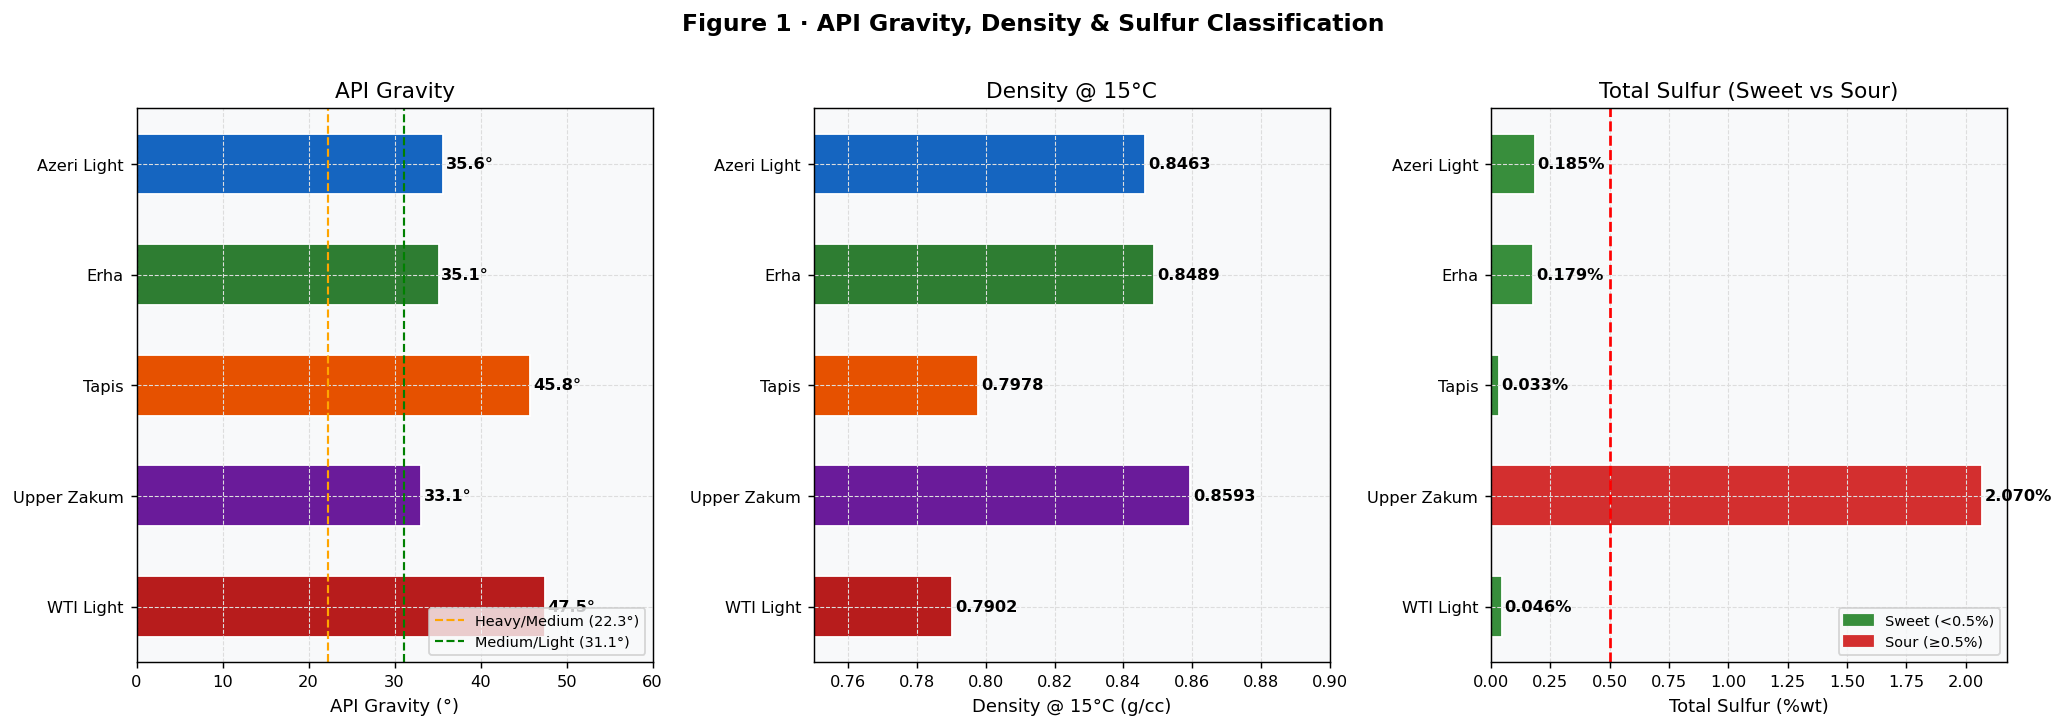

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5.5))
fig.suptitle('Figure 1 · API Gravity, Density & Sulfur Classification', fontsize=13, fontweight='bold', y=1.01)

# Panel A: API Gravity
ax = axes[0]
apis = get_whole_prop(assays, 'API Gravity')
bars = ax.barh(apis.index, apis.values, color=PALETTE, edgecolor='white', height=0.55)
# Classification bands
ax.axvline(22.3, color='orange', ls='--', lw=1.2, label='Heavy/Medium (22.3°)')
ax.axvline(31.1, color='green',  ls='--', lw=1.2, label='Medium/Light (31.1°)')
for bar, val in zip(bars, apis.values):
    ax.text(val + 0.3, bar.get_y() + bar.get_height()/2, f'{val:.1f}°',
            va='center', ha='left', fontsize=9, fontweight='bold')
ax.set_xlabel('API Gravity (°)', fontsize=10)
ax.set_title('API Gravity')
ax.legend(fontsize=8, loc='lower right')
ax.set_xlim(0, 60)
ax.invert_yaxis()

# Panel B: Density @ 15°C
ax = axes[1]
dens = get_whole_prop(assays, 'Density @ 15°C (g/cc)')
bars = ax.barh(dens.index, dens.values, color=PALETTE, edgecolor='white', height=0.55)
for bar, val in zip(bars, dens.values):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2, f'{val:.4f}',
            va='center', ha='left', fontsize=9, fontweight='bold')
ax.set_xlabel('Density @ 15°C (g/cc)', fontsize=10)
ax.set_title('Density @ 15°C')
ax.set_xlim(0.75, 0.90)
ax.invert_yaxis()

# Panel C: Total Sulfur
ax = axes[2]
sulf = get_whole_prop(assays, 'Total Sulfur (% wt)')
colors_s = ['#D32F2F' if s >= 0.5 else '#388E3C' for s in sulf.values]
bars = ax.barh(sulf.index, sulf.values, color=colors_s, edgecolor='white', height=0.55)
ax.axvline(0.5, color='red', ls='--', lw=1.5, label='Sweet/Sour threshold (0.5%)')
for bar, val in zip(bars, sulf.values):
    ax.text(val + 0.01, bar.get_y() + bar.get_height()/2, f'{val:.3f}%',
            va='center', ha='left', fontsize=9, fontweight='bold')
ax.set_xlabel('Total Sulfur (%wt)', fontsize=10)
ax.set_title('Total Sulfur (Sweet vs Sour)')
ax.legend(fontsize=8, loc='lower right')
ax.invert_yaxis()
sweet_patch = mpatches.Patch(color='#388E3C', label='Sweet (<0.5%)')
sour_patch  = mpatches.Patch(color='#D32F2F', label='Sour (≥0.5%)')
ax.legend(handles=[sweet_patch, sour_patch], fontsize=8, loc='lower right')

fig.tight_layout()
plt.show()


Key Observation: Upper Zakum is the only SOUR crude (2.07% S), while Tapis and WTI Light are ultra-sweet (<0.05% S). All crudes are in the Light category (API > 31.1°), with WTI Light and Tapis being the lightest (API ≈ 47–48°).

### Metals, TAN, Viscosity & RVP Comparison

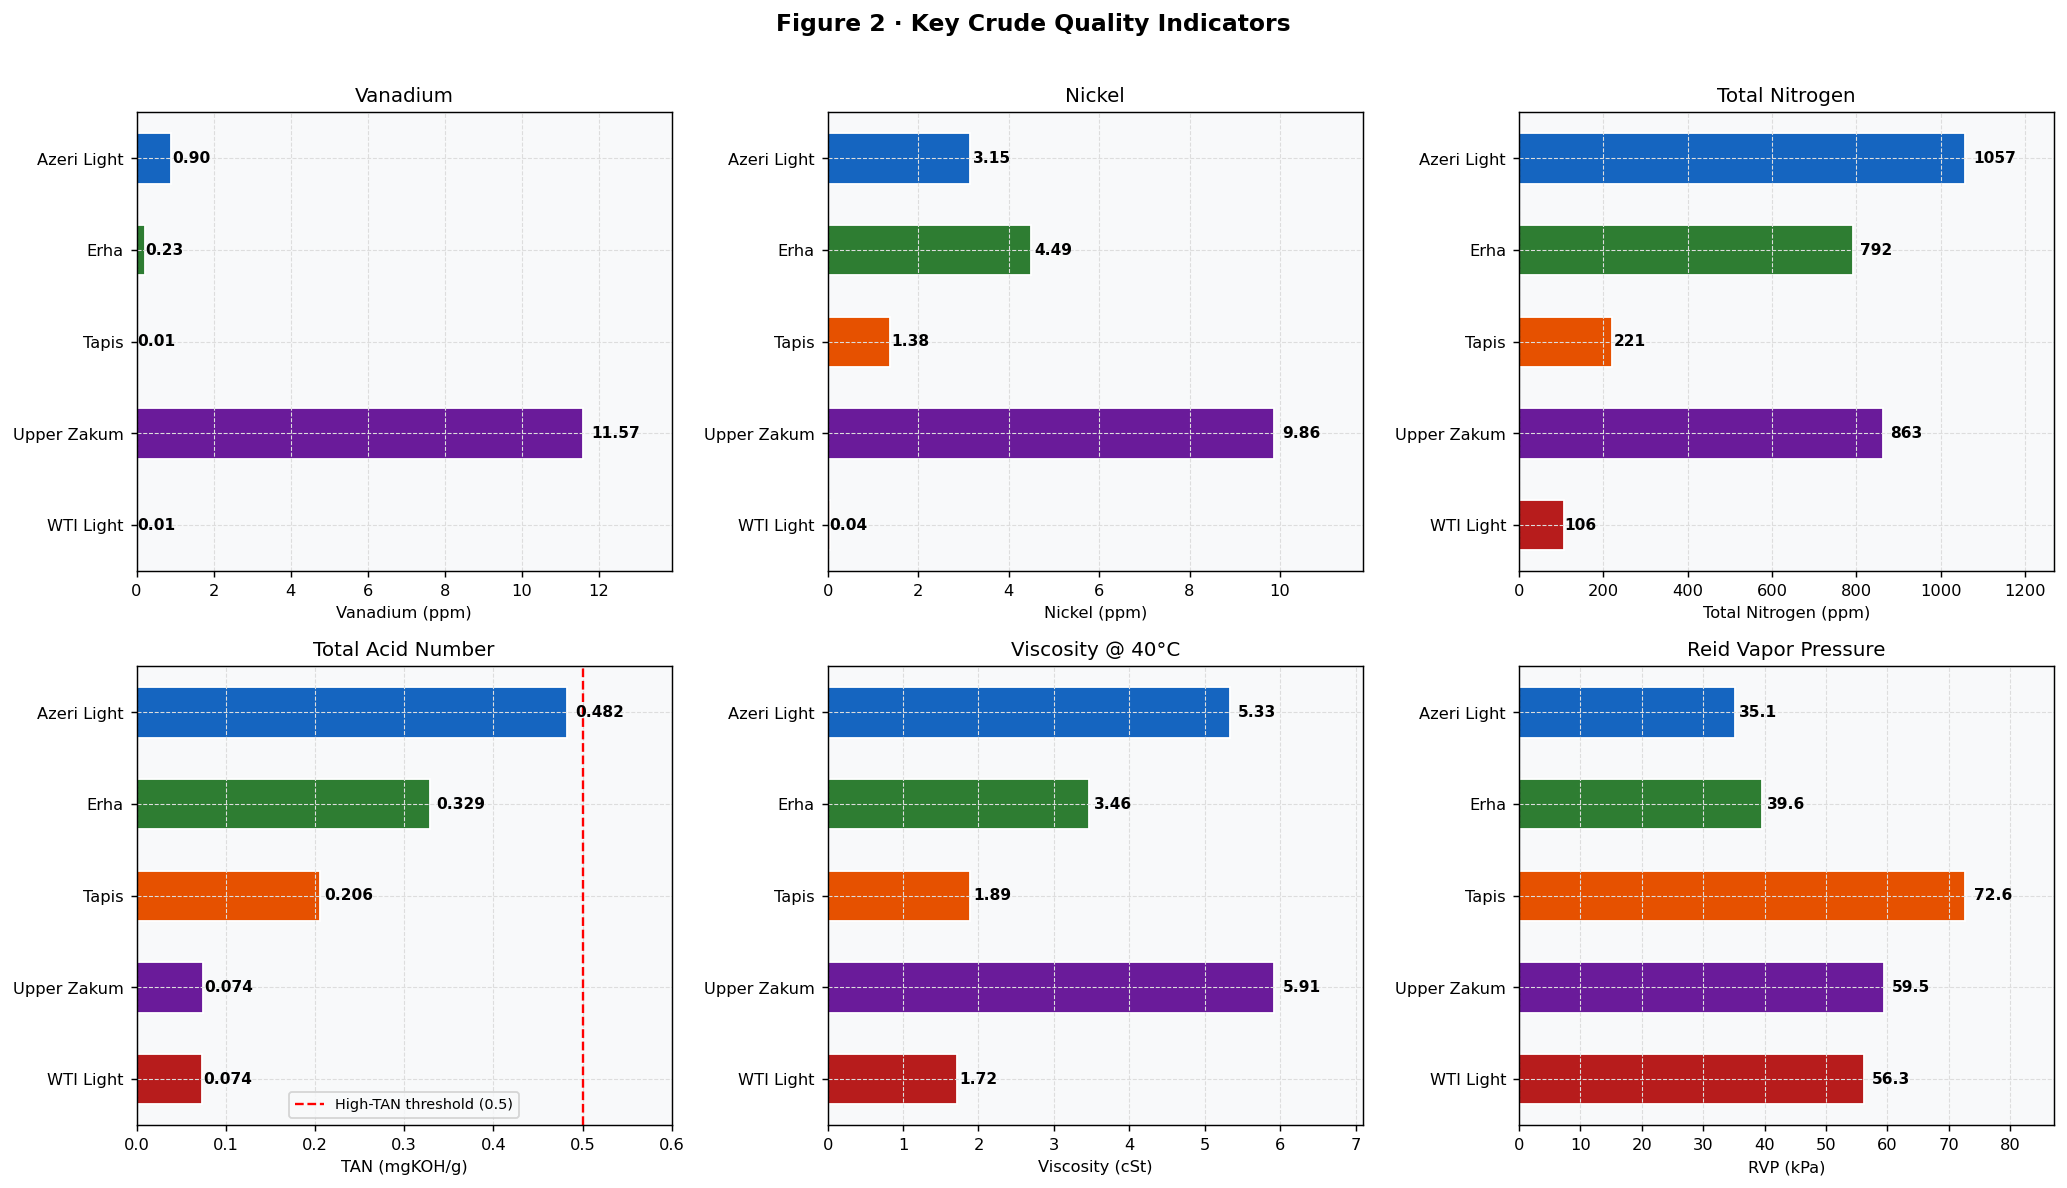

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Figure 2 · Key Crude Quality Indicators', fontsize=13, fontweight='bold', y=1.01)

def bar_h(ax, prop_key, title, xlabel, fmt='.2f', threshold=None, thr_label=''):
    vals = get_whole_prop(assays, prop_key)
    valid = vals.dropna()
    bars = ax.barh(valid.index, valid.values, color=[CRUDE_COLORS[n] for n in valid.index],
                   edgecolor='white', height=0.55)
    if threshold is not None:
        ax.axvline(threshold, color='red', ls='--', lw=1.3, label=thr_label)
        ax.legend(fontsize=8)
    for bar, val in zip(bars, valid.values):
        ax.text(val * 1.02 if val > 0 else val - abs(val) * 0.05,
                bar.get_y() + bar.get_height() / 2,
                format(val, fmt), va='center', ha='left', fontsize=8.5, fontweight='bold')
    ax.set_title(title, fontsize=11)
    ax.set_xlabel(xlabel, fontsize=9)
    ax.invert_yaxis()
    ax.margins(x=0.2)

bar_h(axes[0, 0], 'Vanadium (ppm)',              'Vanadium',            'Vanadium (ppm)')
bar_h(axes[0, 1], 'Nickel (ppm)',                 'Nickel',              'Nickel (ppm)')
bar_h(axes[0, 2], 'Total Nitrogen (ppm)',          'Total Nitrogen',      'Total Nitrogen (ppm)', '.0f')
bar_h(axes[1, 0], 'Total Acid Number (mgKOH/g)',   'Total Acid Number',   'TAN (mgKOH/g)', '.3f',
      threshold=0.5, thr_label='High-TAN threshold (0.5)')
bar_h(axes[1, 1], 'Viscosity @ 40°C (cSt)',        'Viscosity @ 40°C',    'Viscosity (cSt)', '.2f')
bar_h(axes[1, 2], 'Reid Vapor Pressure (kPa)',      'Reid Vapor Pressure', 'RVP (kPa)', '.1f')

fig.tight_layout()
plt.show()


Key Observations:

• Metals (V, Ni): Upper Zakum has the highest Vanadium (11.6 ppm) and Nickel (9.9 ppm) — critical for FCC catalyst poisoning.

• TAN: Azeri Light has the highest TAN (≈0.48 mgKOH/g) — near the 0.5 high-TAN threshold, indicating corrosion risk.

• Nitrogen: Azeri Light has the most nitrogen (>1056 ppm), requiring more intensive hydrotreating.

• Viscosity (40°C): Erha and Azeri Light are more viscous, affecting pumpability and heating requirements.

• RVP: WTI Light shows the highest RVP — more light ends, stricter tank vapour pressure management needed.

---
## Section 2 — Yield Distribution

Yield distribution defines the refinery product slate. The cuts are divided into:

| Fraction | Temperature Range | Typical Products |
|---|---|---|
| Light Ends | IBP – 65°C | LPG, light naphtha feed |
| Light Naphtha | 65 – 100°C | Gasoline blending, petrochem feed |
| Heavy Naphtha | 100 – 150°C | Catalytic reformer feed |
| Kerosene | 150 – 200°C | Jet fuel / heating oil |
| Jet Fuel | 200 – 250°C | Aviation turbine fuel |
| Diesel / AGO | 250 – 350°C | Automotive diesel |
| Atm. Residue | 370°C+ | FCC/hydrocracker feed, fuel oil |
| VGO | 370 – 550°C | FCC / hydrocracker feed |
| Vacuum Residue | 550°C+ | Bitumen, coker feed |

### Yield Distribution — Table & Grouped Bar Chart

In [8]:
# Building yield %wt table
yield_df = get_cut_series(assays, 'Yield (% wt)')

# Renaming columns to friendly names
friendly_cols = [CUT_FRIENDLY.get(c, c).replace('\n', ' ') for c in yield_df.columns]
yield_display = yield_df.copy()
yield_display.columns = friendly_cols
yield_display = yield_display.round(2)
yield_display['TOTAL'] = yield_display.sum(axis=1)

print("Table 2 · Yield (%wt) by Cut\n")
try:
    from IPython.display import display
    styled_y = (yield_display.style
        .set_caption('Table 2 · Yield Distribution (%wt on Crude)')
        .background_gradient(cmap='YlOrRd', subset=yield_display.columns[:-1], axis=None)
        .format('{:.2f}')
        .set_table_styles([
            {'selector': 'th', 'props': [('background-color', '#37474F'), ('color', 'white'),
                                          ('font-size', '10px'), ('padding', '4px 8px'),
                                          ('text-align', 'center')]},
            {'selector': 'td', 'props': [('text-align', 'center'), ('font-size', '10px'), ('padding', '4px 8px')]},
            {'selector': 'caption', 'props': [('font-size', '13px'), ('font-weight', 'bold'), ('padding-bottom', '8px')]},
        ])
    )
    display(styled_y)
except Exception:
    print(yield_display.to_string())


Table 2 · Yield (%wt) by Cut



,Light Ends (C5–65°C),Light Naphtha (65–100°C),Hvy Naphtha (100–150°C),Kerosene (150–200°C),Jet Fuel (200–250°C),Diesel (250–300°C),Lt AGO (300–350°C),Hvy AGO (350–370°C),Atm. Residue (370°C+),LVGO (370–450°C),MVGO (450–500°C),HVGO (500–550°C),Vac. Residue (550°C+),TOTAL
Azeri Light,2.66,4.55,8.14,8.64,9.89,11.01,10.71,3.99,39.48,14.21,7.19,5.59,12.49,138.55
Erha,3.18,5.26,8.56,9.34,11.62,13.32,12.57,4.53,30.54,14.24,5.86,3.94,6.51,129.47
Tapis,5.86,7.18,12.42,11.89,12.17,11.88,10.24,3.54,22.92,11.51,4.10,2.52,4.78,121.01
Upper Zakum,4.30,3.74,7.37,8.31,8.27,8.34,8.20,3.30,46.34,12.91,7.60,6.72,19.11,144.51
WTI Light,5.96,10.23,16.54,12.24,10.21,9.66,8.29,2.89,21.81,9.57,4.43,3.16,4.64,119.63


### Grouped Bar Chart — Yield %wt per Cut

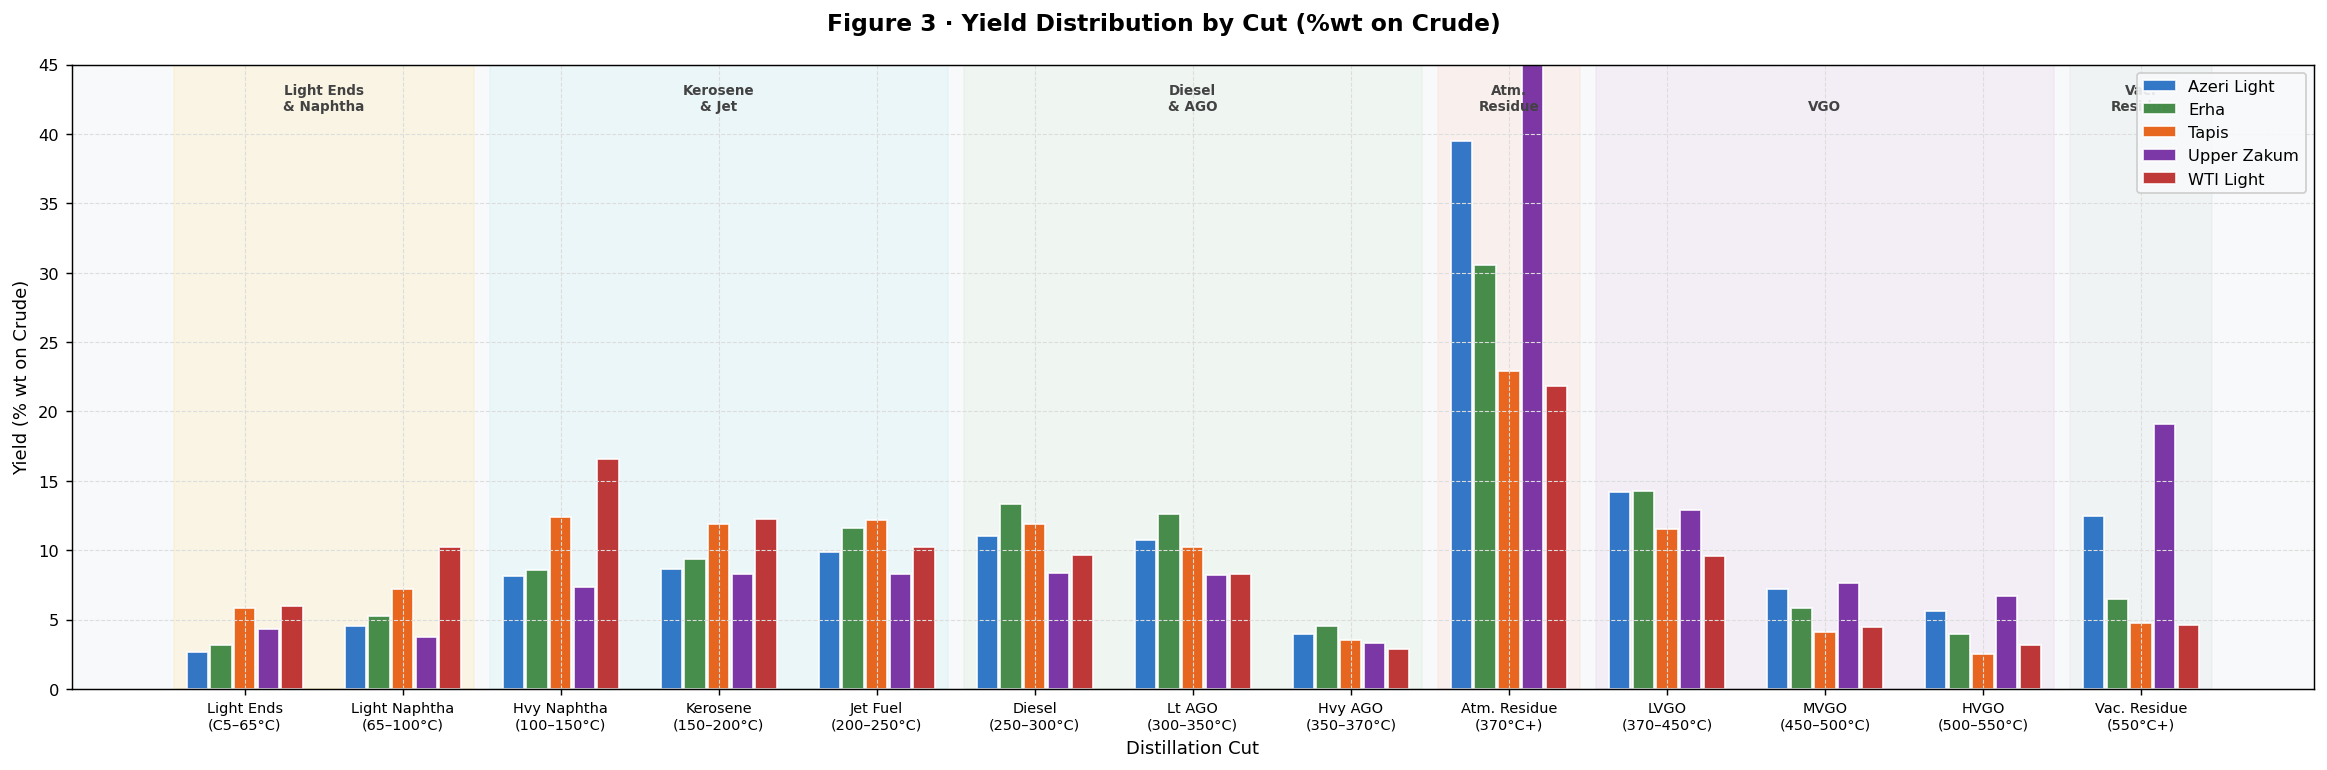

In [9]:
yield_df  = get_cut_series(assays, 'Yield (% wt)')
n_cuts    = len(yield_df.columns)
n_crudes  = len(yield_df)
x_pos     = np.arange(n_cuts)
bar_w     = 0.15
offsets   = np.linspace(-(n_crudes - 1) / 2, (n_crudes - 1) / 2, n_crudes) * bar_w

fig, ax = plt.subplots(figsize=(18, 6))
fig.suptitle('Figure 3 · Yield Distribution by Cut (%wt on Crude)', fontsize=13, fontweight='bold')

for idx, (crude, color) in enumerate(CRUDE_COLORS.items()):
    vals = yield_df.loc[crude].values
    bars = ax.bar(x_pos + offsets[idx], vals, bar_w * 0.9,
                  label=crude, color=color, alpha=0.87, edgecolor='white')

ax.set_xticks(x_pos)
ax.set_xticklabels([CUT_FRIENDLY.get(c, c) for c in yield_df.columns], rotation=0, ha='center', fontsize=8)
ax.set_ylabel('Yield (% wt on Crude)', fontsize=10)
ax.set_xlabel('Distillation Cut', fontsize=10)
ax.legend(loc='upper right', fontsize=9, framealpha=0.9)
ax.set_ylim(0, 45)

# Adding fraction group shading
frac_groups = [(0, 1, '#FFE082', 'Light Ends\n& Naphtha'),
               (2, 4, '#B2EBF2', 'Kerosene\n& Jet'),
               (5, 7, '#C8E6C9', 'Diesel\n& AGO'),
               (8, 8, '#FFCCBC', 'Atm.\nResidue'),
               (9, 11, '#E1BEE7', 'VGO'),
               (12, 12, '#CFD8DC', 'Vac.\nResidue')]
for i_start, i_end, col, lbl in frac_groups:
    ax.axvspan(i_start - 0.45, i_end + 0.45, alpha=0.18, color=col, zorder=0)
    ax.text((i_start + i_end) / 2, 41.5, lbl, ha='center', va='bottom', fontsize=7.5,
            color='#424242', fontweight='bold')

fig.tight_layout()
plt.show()



Key Observations:

• Atmospheric Residue (370°C+): All crudes show a significant residue yield (35–55% wt).

• WTI Light and Tapis are lightest — higher light naphtha and middle distillate yields.

• Upper Zakum has the highest atmospheric residue yield, reflecting its lower API gravity.

• Erha shows a notably high diesel fraction yield, making it attractive for diesel-focused refineries.

### Stacked Yield Bar Chart + TBP Distillation Curve

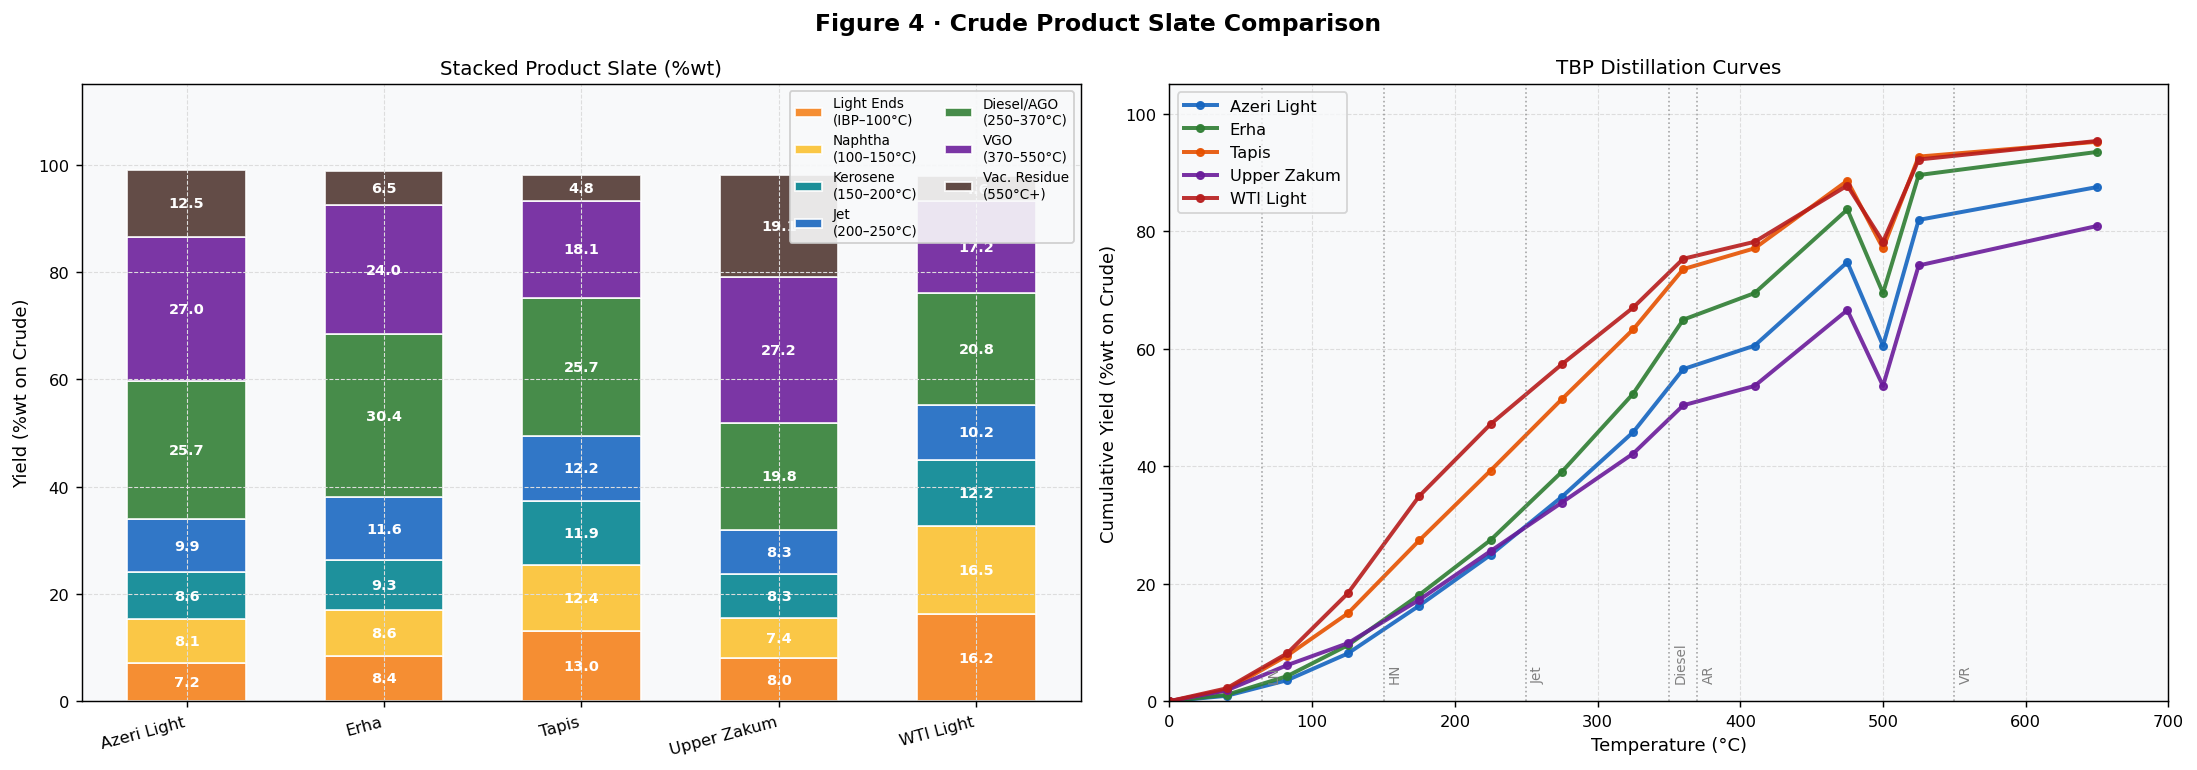

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(17, 6))
fig.suptitle('Figure 4 · Crude Product Slate Comparison', fontsize=13, fontweight='bold')

# Panel A: Stacked fraction yield
yield_df = get_cut_series(assays, 'Yield (% wt)')

# Aggregating into product fractions
def agg_frac(crude_yields, col_list):
    """Sum yields for given cut columns that exist."""
    available = [c for c in col_list if c in crude_yields.columns]
    return crude_yields[available].sum(axis=1) if available else pd.Series(0, index=crude_yields.index)

# Map cut labels
cut_cols = yield_df.columns.tolist()

# Building friendly aggregated fractions
def find_cuts(patterns):
    return [c for c in cut_cols if any(p in c for p in patterns)]

light_ends  = find_cuts(['C5', '65-100', '65.0-100'])
naphtha     = find_cuts(['100-150', '100.0-150'])
kerosene    = find_cuts(['150-200', '150.0-200'])
jet         = find_cuts(['200-250', '200.0-250'])
diesel      = find_cuts(['250-300', '250.0-300', '300-350', '300.0-350', '350-370', '350.0-370'])
vgo         = find_cuts(['370-450', '370.0-450', '450-500', '450.0-500', '500-550', '500.0-550'])
vac_res     = find_cuts(['550-FBP', '550.0-FBP'])

frac_map = {
    'Light Ends\n(IBP–100°C)': light_ends,
    'Naphtha\n(100–150°C)':    naphtha,
    'Kerosene\n(150–200°C)':   kerosene,
    'Jet\n(200–250°C)':        jet,
    'Diesel/AGO\n(250–370°C)': diesel,
    'VGO\n(370–550°C)':        vgo,
    'Vac. Residue\n(550°C+)':  vac_res,
}
frac_colors = ['#F57F17', '#FBC02D', '#00838F', '#1565C0', '#2E7D32', '#6A1B9A', '#4E342E']

stacked = {}
for label, cols in frac_map.items():
    stacked[label] = agg_frac(yield_df, cols)
stacked_df = pd.DataFrame(stacked)

bottom = np.zeros(len(CRUDE_NAMES))
x_pos = np.arange(len(CRUDE_NAMES))
for (frac_label, s_data), fc in zip(stacked_df.items(), frac_colors):
    vals = [s_data.get(cn, 0) for cn in CRUDE_NAMES]
    bars = ax1.bar(x_pos, vals, bottom=bottom, label=frac_label, color=fc, alpha=0.88, edgecolor='white', width=0.6)
    # Add value labels inside bars if large enough
    for xi, (b, v) in enumerate(zip(bottom, vals)):
        if v > 3:
            ax1.text(xi, b + v / 2, f'{v:.1f}', ha='center', va='center',
                     fontsize=8, color='white', fontweight='bold')
    bottom += np.array(vals)

ax1.set_xticks(x_pos)
ax1.set_xticklabels(CRUDE_NAMES, rotation=15, ha='right', fontsize=9)
ax1.set_ylabel('Yield (%wt on Crude)', fontsize=10)
ax1.set_title('Stacked Product Slate (%wt)', fontsize=11)
ax1.legend(loc='upper right', fontsize=7.5, framealpha=0.9, ncol=2)
ax1.set_ylim(0, 115)

# Panel B: Cumulative TBP Distillation Curve
cum_yield_df = get_cut_series(assays, 'Cumulative Yield (% wt)')

# Map cut labels to mid-point temperatures for TBP
cut_mid_temps = {
    'C5-65': 40, 'C5-65.0': 40,
    '65-100': 82.5, '65.0-100.0': 82.5,
    '100-150': 125, '100.0-150.0': 125,
    '150-200': 175, '150.0-200.0': 175,
    '200-250': 225, '200.0-250.0': 225,
    '250-300': 275, '250.0-300.0': 275,
    '300-350': 325, '300.0-350.0': 325,
    '350-370': 360, '350.0-370.0': 360,
    '370-FBP': 500, '370.0-FBP': 500,
    '370-450': 410, '370.0-450.0': 410,
    '450-500': 475, '450.0-500.0': 475,
    '500-550': 525, '500.0-550.0': 525,
    '550-FBP': 650, '550.0-FBP': 650,
}

for crude, color in CRUDE_COLORS.items():
    if crude not in cum_yield_df.index:
        continue
    row = cum_yield_df.loc[crude]
    temps = []
    yields = []
    for cut_label, cum_y in row.items():
        t = cut_mid_temps.get(cut_label)
        if t is not None and not np.isnan(cum_y):
            temps.append(t)
            yields.append(cum_y)
    if temps:
        # Sort by temp
        pairs = sorted(zip(temps, yields))
        t_arr = [0] + [p[0] for p in pairs]
        y_arr = [0] + [p[1] for p in pairs]
        ax2.plot(t_arr, y_arr, color=color, lw=2.2, marker='o', markersize=4,
                 label=crude, alpha=0.9)

# Adding refinery cut demarcation lines
cut_boundaries = [(65,'LN'), (150,'HN'), (250,'Jet'), (350,'Diesel'), (370,'AR'), (550,'VR')]
for temp, label in cut_boundaries:
    ax2.axvline(temp, color='gray', ls=':', lw=0.9, alpha=0.7)
    ax2.text(temp + 3, 3, label, fontsize=7.5, color='gray', rotation=90, va='bottom')

ax2.set_xlabel('Temperature (°C)', fontsize=10)
ax2.set_ylabel('Cumulative Yield (%wt on Crude)', fontsize=10)
ax2.set_title('TBP Distillation Curves', fontsize=11)
ax2.legend(loc='upper left', fontsize=9)
ax2.set_xlim(0, 700)
ax2.set_ylim(0, 105)

fig.tight_layout()
plt.show()


Key Observations:

• WTI Light and Tapis distillation curves rise steeply at lower temperatures → higher light fraction yields.

• Upper Zakum's TBP curve lags the others at mid-range temperatures, confirming heavier composition.

• By 350°C, Tapis yields ~70%wt vs ~55%wt for Upper Zakum — a 15 percentage point difference in distillable fraction.

• All crudes carry significant bottom-of-barrel material, but Erha has notably high atmospheric residue.


---
## Section 3 — Cut Properties Profiles

The following charts trace how **density, API gravity, sulfur, nitrogen, TAN, and viscosity** evolve along the distillation curve from the lightest cuts to the heaviest residue.  
Generally heavier cuts are denser, more sulfur-rich, and more viscous.  Understanding these profiles informs how much treating each fraction will require.

### Cut Properties Profiles — Density, API, Sulfur, Nitrogen

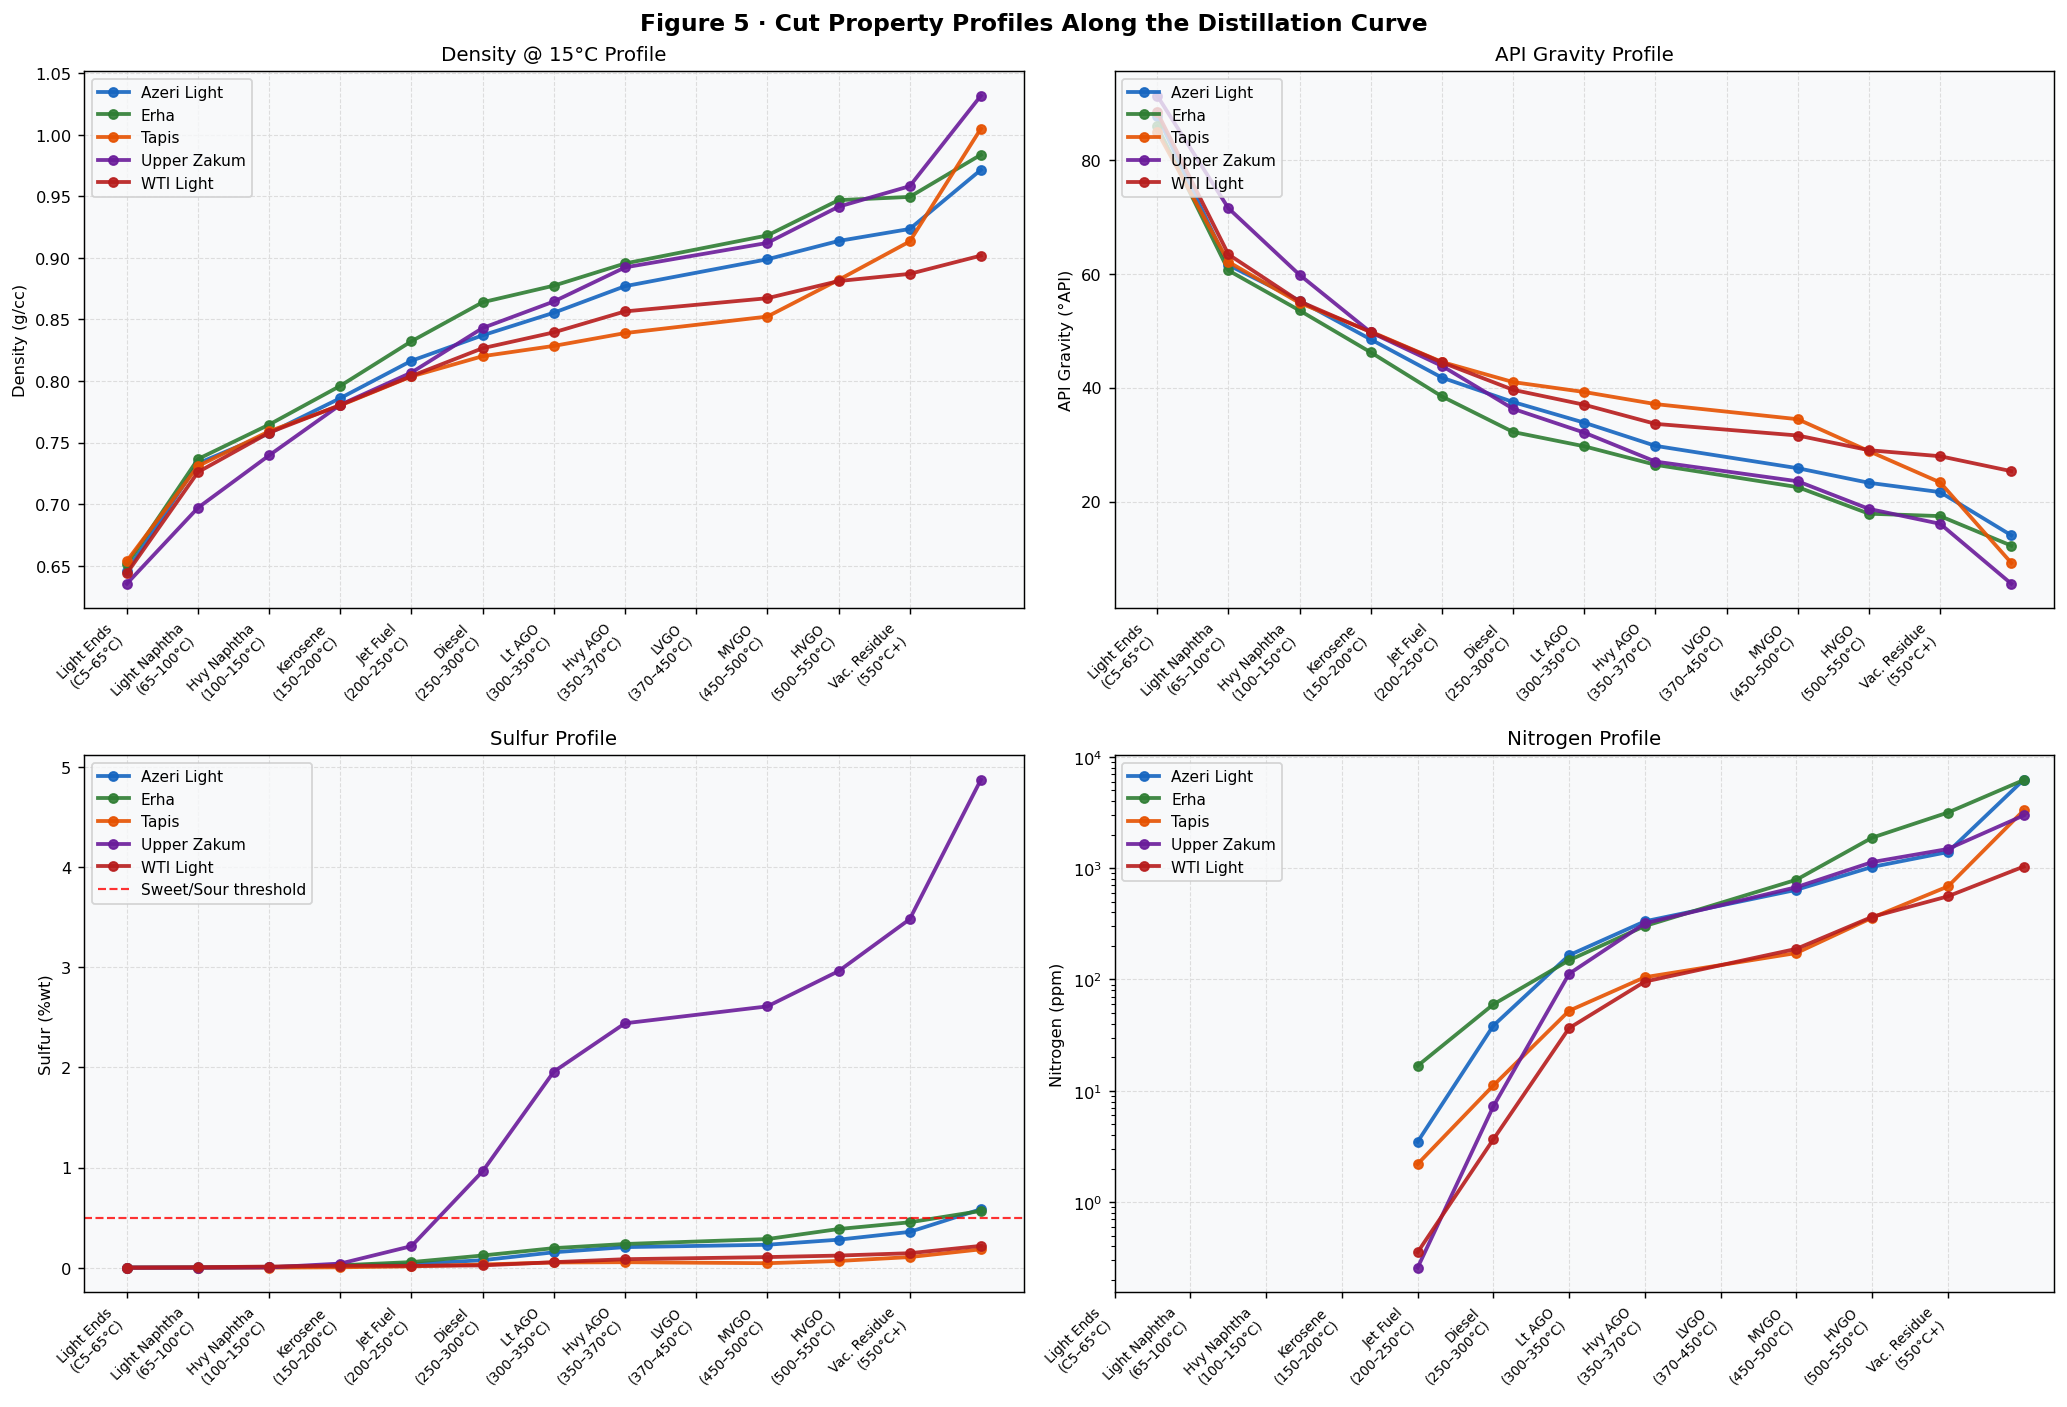

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle('Figure 5 · Cut Property Profiles Along the Distillation Curve', fontsize=13, fontweight='bold')

# Helper: plotting line profile
def plot_profile(ax, prop_key, ylabel, title, y_log=False, threshold=None, thr_label=''):
    df = get_cut_series(assays, prop_key)
    # Excluding the atmospheric residue whole cut (col 8 = 370-FBP) if vacuum sub-cuts are present
    # to avoid double-counting; keep the VGO sub-cuts instead for continuity
    for crude, color in CRUDE_COLORS.items():
        if crude not in df.index:
            continue
        row = df.loc[crude]
        cuts = df.columns.tolist()
        # Skipping 370-FBP (index 8) because it overlaps with vacuum cuts 9-12
        valid_cuts = [(i, c) for i, c in enumerate(cuts) if '370-FBP' not in c and '370.0-FBP' not in c]
        x_vals, y_vals, x_labels = [], [], []
        for i, c in valid_cuts:
            v = row[c]
            if not np.isnan(v):
                x_vals.append(i)
                y_vals.append(v)
                x_labels.append(c)
        if len(x_vals) > 1:
            ax.plot(x_vals, y_vals, color=color, lw=2.1, marker='o', markersize=5,
                    label=crude, alpha=0.9)
    if threshold:
        ax.axhline(threshold, color='red', ls='--', lw=1.2, alpha=0.8, label=thr_label)
        ax.legend(fontsize=8)
    # X-ticks
    df_plot = get_cut_series(assays, prop_key)
    cuts_for_ticks = [c for c in df_plot.columns if '370-FBP' not in c and '370.0-FBP' not in c]
    ax.set_xticks(range(len(cuts_for_ticks)))
    ax.set_xticklabels([CUT_FRIENDLY.get(c, c) for c in cuts_for_ticks], rotation=45, ha='right', fontsize=7.5)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.set_title(title, fontsize=11)
    if y_log:
        ax.set_yscale('log')
    ax.legend(fontsize=8.5, loc='upper left')

plot_profile(axes[0, 0], 'Density @ 15°C (g/cc)',   'Density (g/cc)',       'Density @ 15°C Profile')
plot_profile(axes[0, 1], 'API Gravity',              'API Gravity (°API)',   'API Gravity Profile')
plot_profile(axes[1, 0], 'Total Sulfur (% wt)',      'Sulfur (%wt)',         'Sulfur Profile',
             threshold=0.5, thr_label='Sweet/Sour threshold')
plot_profile(axes[1, 1], 'Total Nitrogen (ppm)',     'Nitrogen (ppm)',       'Nitrogen Profile', y_log=True)

fig.tight_layout()
plt.show()

Key Observations:

• Density/API: All crudes show increasing density (decreasing API) with rising cut temperature. Tapis and WTI Light are notably lighter across ALL cut ranges.

• Sulfur: Upper Zakum's sulfur content is dramatically higher in every cut — even its lightest fractions exceed 0.3%wt sulfur, requiring extensive hydrotreating.

• Nitrogen: Azeri Light has the highest nitrogen across mid-range cuts. Azeri and Erha residues have very high nitrogen, impacting FCC catalyst life.

• The rapid sulfur rise in heavier fractions (>300°C) is a refinery challenge for all crudes — heavier sulfur species concentrate in the residue.

#### Cut Properties Profiles — TAN, Viscosity & UOPK

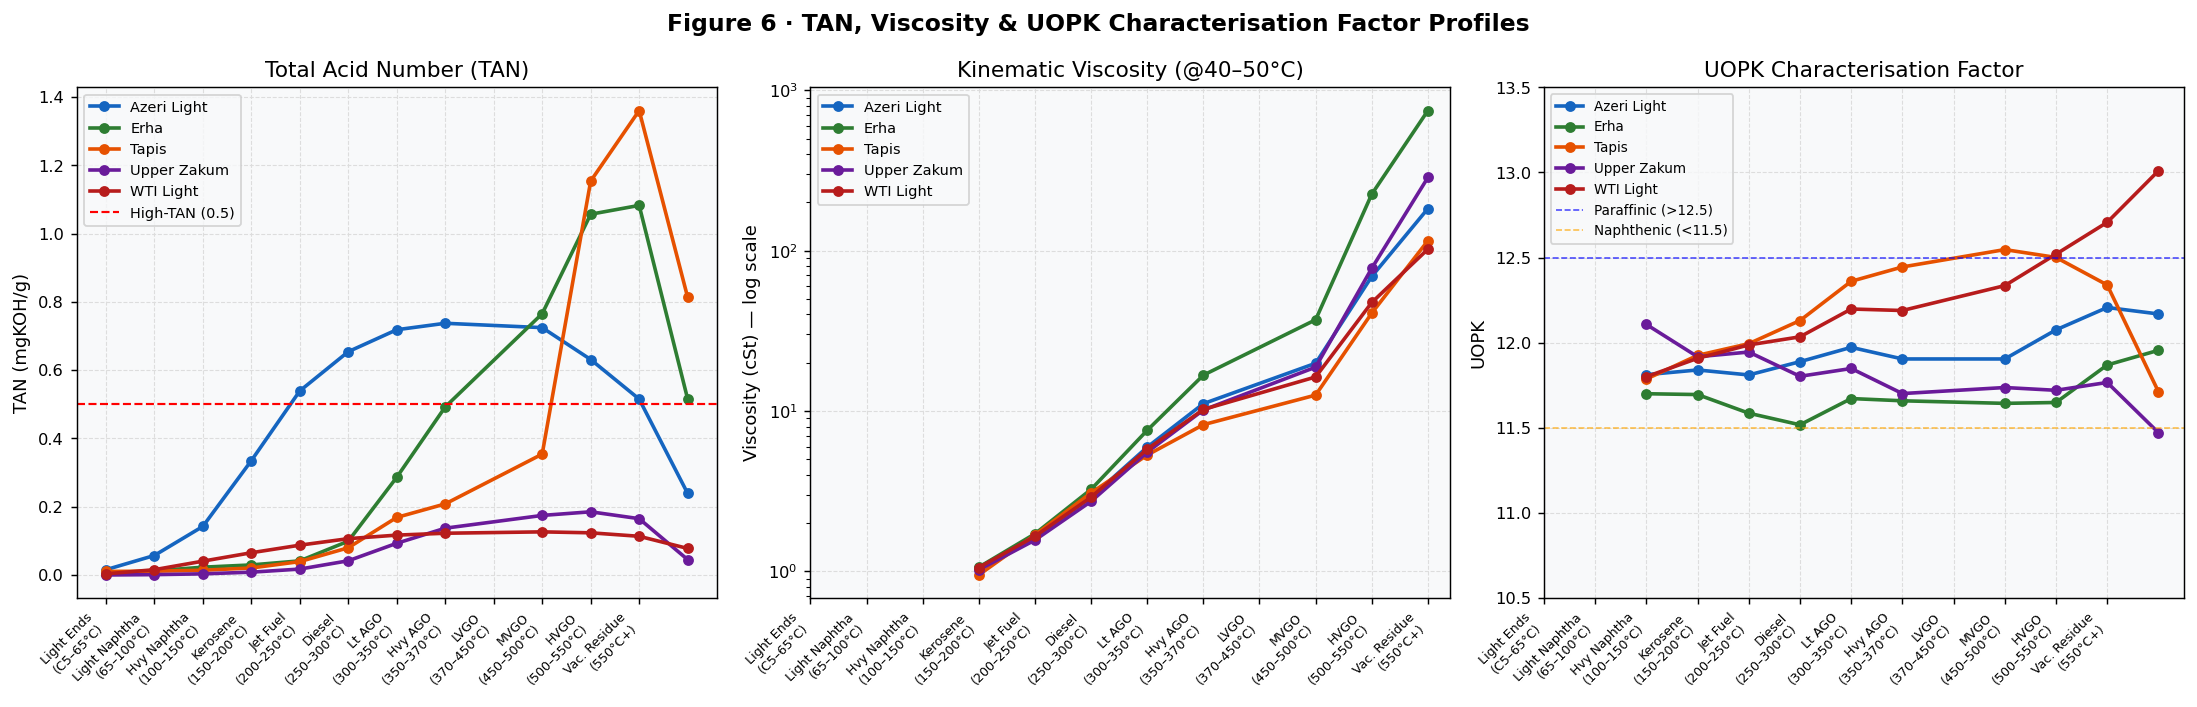

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5.5))
fig.suptitle('Figure 6 · TAN, Viscosity & UOPK Characterisation Factor Profiles', fontsize=13, fontweight='bold')

# Re-using plot_profile from above

# Panel A: TAN
ax = axes[0]
df_tan = get_cut_series(assays, 'Total Acid Number (mgKOH/g)')
for crude, color in CRUDE_COLORS.items():
    if crude not in df_tan.index:
        continue
    row = df_tan.loc[crude]
    x_v, y_v = [], []
    for i, (c, v) in enumerate(row.items()):
        if '370-FBP' not in c and '370.0-FBP' not in c and not np.isnan(v):
            x_v.append(i); y_v.append(v)
    if len(x_v) > 1:
        ax.plot(x_v, y_v, color=color, lw=2, marker='o', ms=5, label=crude)
ax.axhline(0.5, color='red', ls='--', lw=1.2, label='High-TAN (0.5)')
ax.set_title('Total Acid Number (TAN)')
ax.set_ylabel('TAN (mgKOH/g)')
ax.legend(fontsize=8)
ref_cuts = [c for c in df_tan.columns if '370-FBP' not in c and '370.0-FBP' not in c]
ax.set_xticks(range(len(ref_cuts)))
ax.set_xticklabels([CUT_FRIENDLY.get(c, c) for c in ref_cuts], rotation=45, ha='right', fontsize=7)

# Panel B: Viscosity @ multiple temps
ax = axes[1]
# Using best available viscosity per cut
visc_props = ['Viscosity @ 40°C (cSt)', 'Viscosity @ 50°C (cSt)']
df_v40 = get_cut_series(assays, 'Viscosity @ 40°C (cSt)')
df_v50 = get_cut_series(assays, 'Viscosity @ 50°C (cSt)')

for crude, color in CRUDE_COLORS.items():
    combined_x, combined_y = [], []
    for df_v in [df_v40, df_v50]:
        if crude not in df_v.index:
            continue
        row = df_v.loc[crude]
        for i, (c, v) in enumerate(row.items()):
            if '370-FBP' not in c and '370.0-FBP' not in c and not np.isnan(v) and v > 0:
                if i not in combined_x:
                    combined_x.append(i)
                    combined_y.append(v)
    if len(combined_x) > 1:
        pairs = sorted(zip(combined_x, combined_y))
        ax.plot([p[0] for p in pairs], [p[1] for p in pairs],
                color=color, lw=2, marker='o', ms=5, label=crude)
ax.set_yscale('log')
ax.set_title('Kinematic Viscosity (@40–50°C)')
ax.set_ylabel('Viscosity (cSt) — log scale')
ax.legend(fontsize=8)
ax.set_xticks(range(len(ref_cuts)))
ax.set_xticklabels([CUT_FRIENDLY.get(c, c) for c in ref_cuts], rotation=45, ha='right', fontsize=7)

# Panel C: UOPK Characterisation Factor
ax = axes[2]
df_uopk = get_cut_series(assays, 'UOPK')
for crude, color in CRUDE_COLORS.items():
    if crude not in df_uopk.index:
        continue
    row = df_uopk.loc[crude]
    x_v, y_v = [], []
    for i, (c, v) in enumerate(row.items()):
        if '370-FBP' not in c and '370.0-FBP' not in c and not np.isnan(v):
            x_v.append(i); y_v.append(v)
    if len(x_v) > 1:
        ax.plot(x_v, y_v, color=color, lw=2, marker='o', ms=5, label=crude)
# UOPK reference lines
ax.axhline(12.5, color='blue',  ls='--', lw=0.9, alpha=0.7, label='Paraffinic (>12.5)')
ax.axhline(11.5, color='orange',ls='--', lw=0.9, alpha=0.7, label='Naphthenic (<11.5)')
ax.set_title('UOPK Characterisation Factor')
ax.set_ylabel('UOPK')
ax.legend(fontsize=7.5)
ax.set_xticks(range(len(ref_cuts)))
ax.set_xticklabels([CUT_FRIENDLY.get(c, c) for c in ref_cuts], rotation=45, ha='right', fontsize=7)
ax.set_ylim(10.5, 13.5)

fig.tight_layout()
plt.show()


Key Observations:

• TAN: Azeri Light peaks in the kerosene-diesel range with TAN > 0.5 — high-TAN crude requiring corrosion inhibitors.

  Erha also shows elevated TAN in middle distillates; Tapis and Upper Zakum are low-TAN.

• Viscosity: Atmospheric residue and VGO cuts of all crudes are highly viscous (10–200+ cSt).

  Tapis and WTI Light maintain lower viscosity even in heavy cuts, easing transport and processing.

• UOPK: All five crudes have UOPK between 11.7–12.5 (paraffinic-naphthenic mixed character).

  Tapis and WTI Light show higher UOPK — more paraffinic character, better yield of paraffin-rich products.

---
## Section 4 — Naphtha & Light Ends Quality

Naphtha (IBP–150°C) is the primary petrochemical and gasoline feed. Key quality parameters are:
- **RON/MON**: Octane numbers determining gasoline blending value
- **PNA composition**: Paraffins / Naphthenes / Aromatics breakdown for reformer feedstock assessment
- **Yield**: How much naphtha each crude produces

#### Naphtha Quality — Yield, RON/MON, PNA Composition

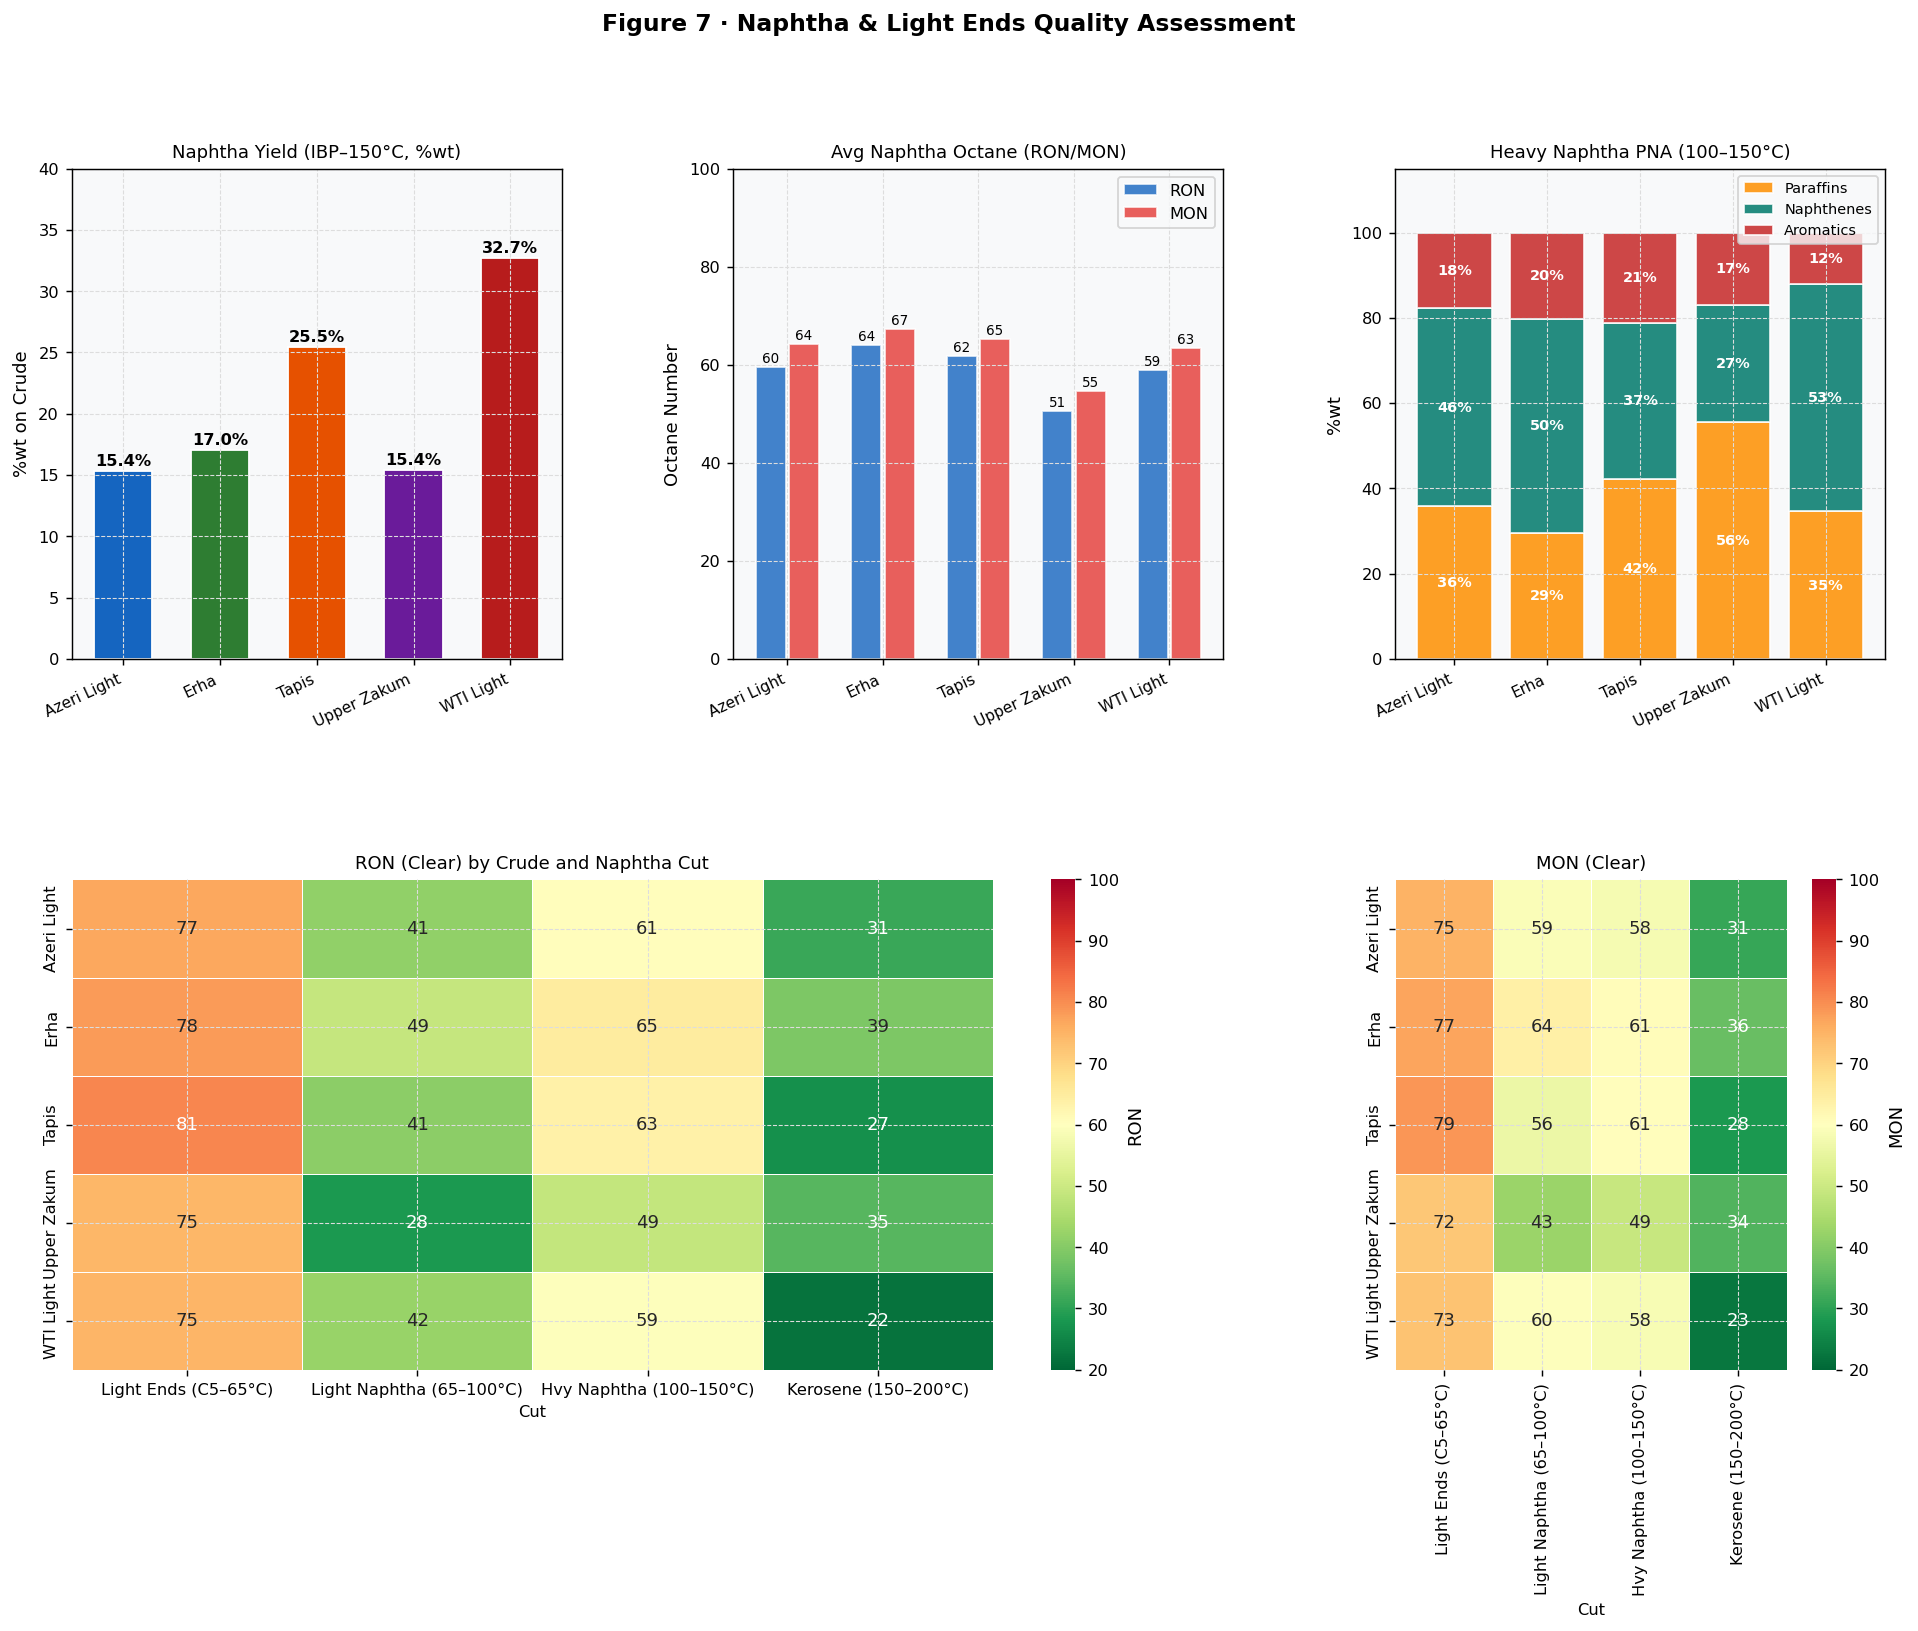

In [24]:
fig = plt.figure(figsize=(18, 12))
fig.suptitle('Figure 7 · Naphtha & Light Ends Quality Assessment', fontsize=13, fontweight='bold')
gs = GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

# Panel A: Naphtha Yield (IBP–150°C)
ax_yield = fig.add_subplot(gs[0, 0])
yield_df = get_cut_series(assays, 'Yield (% wt)')
naphtha_cuts_keys = [c for c in yield_df.columns if any(k in c for k in ['C5', '65-', '65.0-', '100-', '100.0-'])]
naphtha_yield = yield_df[naphtha_cuts_keys].sum(axis=1)
bars = ax_yield.bar(naphtha_yield.index, naphtha_yield.values,
                    color=PALETTE, edgecolor='white', width=0.6)
for bar, val in zip(bars, naphtha_yield.values):
    ax_yield.text(bar.get_x() + bar.get_width()/2, val + 0.2, f'{val:.1f}%',
                  ha='center', va='bottom', fontsize=9, fontweight='bold')
ax_yield.set_title('Naphtha Yield (IBP–150°C, %wt)', fontsize=10)
ax_yield.set_ylabel('%wt on Crude')
ax_yield.set_xticklabels(naphtha_yield.index, rotation=25, ha='right', fontsize=8.5)
ax_yield.set_ylim(0, 40)

# Panel B: RON (Clear) vs MON (Clear)
ax_octane = fig.add_subplot(gs[0, 1])
# For each crude, getting RON/MON for light naphtha (C5-65) and heavy naphtha (65-100)
ron_df = get_cut_series(assays, 'RON (Clear)')
mon_df = get_cut_series(assays, 'MON (Clear)')

ron_cols = [c for c in ron_df.columns if any(k in c for k in ['C5', '65-', '65.0-', '100-', '100.0-'])]
mon_cols = [c for c in mon_df.columns if any(k in c for k in ['C5', '65-', '65.0-', '100-', '100.0-'])]

x = np.arange(len(CRUDE_NAMES))
w = 0.35
for j, (cuts, color, label_suffix) in enumerate([(ron_cols, '#1565C0', 'RON'), (mon_cols, '#E53935', 'MON')]):
    col_vals = []
    for cn in CRUDE_NAMES:
        df_ref = ron_df if label_suffix == 'RON' else mon_df
        if cn in df_ref.index:
            sub = df_ref.loc[cn, cuts].dropna()
            col_vals.append(sub.mean() if len(sub) > 0 else np.nan)
        else:
            col_vals.append(np.nan)
    valid_x = [i for i, v in enumerate(col_vals) if not np.isnan(v)]
    valid_y = [v for v in col_vals if not np.isnan(v)]
    valid_labels = [CRUDE_NAMES[i] for i in valid_x]
    ax_octane.bar([xi + j * w for xi in valid_x], valid_y, w * 0.9,
                  color=color, label=label_suffix, alpha=0.8, edgecolor='white')
    for xi, val in zip(valid_x, valid_y):
        ax_octane.text(xi + j * w, val + 0.3, f'{val:.0f}', ha='center', va='bottom', fontsize=7.5)
ax_octane.set_title('Avg Naphtha Octane (RON/MON)', fontsize=10)
ax_octane.set_ylabel('Octane Number')
ax_octane.set_xticks(x + w / 2)
ax_octane.set_xticklabels(CRUDE_NAMES, rotation=25, ha='right', fontsize=8.5)
ax_octane.legend(fontsize=9)
ax_octane.set_ylim(0, 100)

# Panel C: Paraffins / Naphthenes / Aromatics
ax_pna = fig.add_subplot(gs[0, 2])
par_df = get_cut_series(assays, 'Paraffins (% wt)')
nap_df = get_cut_series(assays, 'Naphthenes (%wt)')
aro_df = get_cut_series(assays, 'Aromatics (% wt)')
# Taking Heavy naphtha (100-150) as the key reformer feed cut
hvy_naph_col = [c for c in par_df.columns if '100' in c and '150' in c]
if hvy_naph_col:
    hc = hvy_naph_col[0]
    pna_data = []
    for cn in CRUDE_NAMES:
        p = par_df.loc[cn, hc] if cn in par_df.index and hc in par_df.columns else np.nan
        n = nap_df.loc[cn, hc] if cn in nap_df.index and hc in nap_df.columns else np.nan
        a = aro_df.loc[cn, hc] if cn in aro_df.index and hc in aro_df.columns else np.nan
        pna_data.append((cn, p, n, a))
    pna_colors = ['#FF8F00', '#00796B', '#C62828']
    x3 = np.arange(len(pna_data))
    bottom = np.zeros(len(pna_data))
    for comp, color_pna in zip(['Paraffins', 'Naphthenes', 'Aromatics'], pna_colors):
        vals = [d[1] if comp == 'Paraffins' else (d[2] if comp == 'Naphthenes' else d[3]) for d in pna_data]
        valid_y = [v if not np.isnan(v) else 0 for v in vals]
        bars2 = ax_pna.bar(x3, valid_y, bottom=bottom, label=comp, color=color_pna, alpha=0.85, edgecolor='white')
        for i, (bar, v) in enumerate(zip(bars2, valid_y)):
            if v > 5:
                ax_pna.text(bar.get_x() + bar.get_width()/2, bottom[i] + v/2,
                            f'{v:.0f}%', ha='center', va='center', fontsize=8, color='white', fontweight='bold')
        bottom += np.array(valid_y)
    ax_pna.set_title('Heavy Naphtha PNA (100–150°C)', fontsize=10)
    ax_pna.set_ylabel('%wt')
    ax_pna.set_xticks(x3)
    ax_pna.set_xticklabels([d[0] for d in pna_data], rotation=25, ha='right', fontsize=8.5)
    ax_pna.legend(fontsize=8)
    ax_pna.set_ylim(0, 115)

# Panels D–F: Cut-level RON/MON, individual naphtha cuts
cuts_to_show = [c for c in ron_df.columns if any(k in c for k in ['C5-', 'C5.0-', '65-', '65.0-', '100-', '100.0-', '150-', '150.0-'])]
cut_cols_sub = cuts_to_show[:4] if len(cuts_to_show) >= 4 else cuts_to_show
cut_names_sub = [CUT_FRIENDLY.get(c, c).replace('\n', ' ') for c in cut_cols_sub]

# RON heatmap
ax_ron_hm = fig.add_subplot(gs[1, :2])
ron_sub = ron_df[cut_cols_sub].copy() if all(c in ron_df.columns for c in cut_cols_sub) else pd.DataFrame()
if not ron_sub.empty:
    sns.heatmap(ron_sub, annot=True, fmt='.0f', cmap='RdYlGn_r',
                linewidths=0.5, linecolor='white', ax=ax_ron_hm,
                xticklabels=cut_names_sub, yticklabels=ron_sub.index,
                cbar_kws={'label': 'RON'}, vmin=20, vmax=100)
    ax_ron_hm.set_title('RON (Clear) by Crude and Naphtha Cut', fontsize=10)
    ax_ron_hm.set_xlabel('Cut', fontsize=9)
    ax_ron_hm.set_ylabel('')

# MON heatmap
ax_mon_hm = fig.add_subplot(gs[1, 2])
mon_sub = mon_df[cut_cols_sub].copy() if all(c in mon_df.columns for c in cut_cols_sub) else pd.DataFrame()
if not mon_sub.empty:
    sns.heatmap(mon_sub, annot=True, fmt='.0f', cmap='RdYlGn_r',
                linewidths=0.5, linecolor='white', ax=ax_mon_hm,
                xticklabels=cut_names_sub, yticklabels=mon_sub.index,
                cbar_kws={'label': 'MON'}, vmin=20, vmax=100)
    ax_mon_hm.set_title('MON (Clear)', fontsize=10)
    ax_mon_hm.set_xlabel('Cut', fontsize=9)
    ax_mon_hm.set_ylabel('')

plt.show()


Key Observations:

• WTI Light has the highest naphtha yield (~25%wt IBP-150°C), followed by Tapis (~25%wt).

• Light naphtha (C5-65°C): RON can be very high for paraffinic crudes (WTI, Tapis), but light-ends RON is unstable.

• Heavy naphtha (100-150°C) PNA: Tapis and WTI Light are more paraffinic (~35%P), making them excellent reformer feeds.

  Higher aromatics in Azeri Light naphtha indicates better pre-reformed octane but less potential for octane uplift.
  
• Azeri Light and Erha heavy naphtha has higher naphthene content — ideal for dehydrogenation to aromatics in a reformer.

---
## Section 5 — Middle Distillates: Kerosene, Jet Fuel & Diesel

Middle distillates (150–350°C) are high-value products. Key quality indicators are:
- **Cetane Index**: Diesel ignition quality (target >51 for Euro V)
- **Freeze Point**: Jet fuel cold-weather operability (Jet A-1 spec: ≤ −47°C)
- **Smoke Point**: Burning quality of kerosene/jet fuel (higher is better, target >25 mm)
- **Naphthalenes (%vol)**: Spec limit <3% vol for Jet A-1
- **Aniline Point**: Indicator of aromatic content / compatibility with rubber seals

#### Middle Distillate Quality

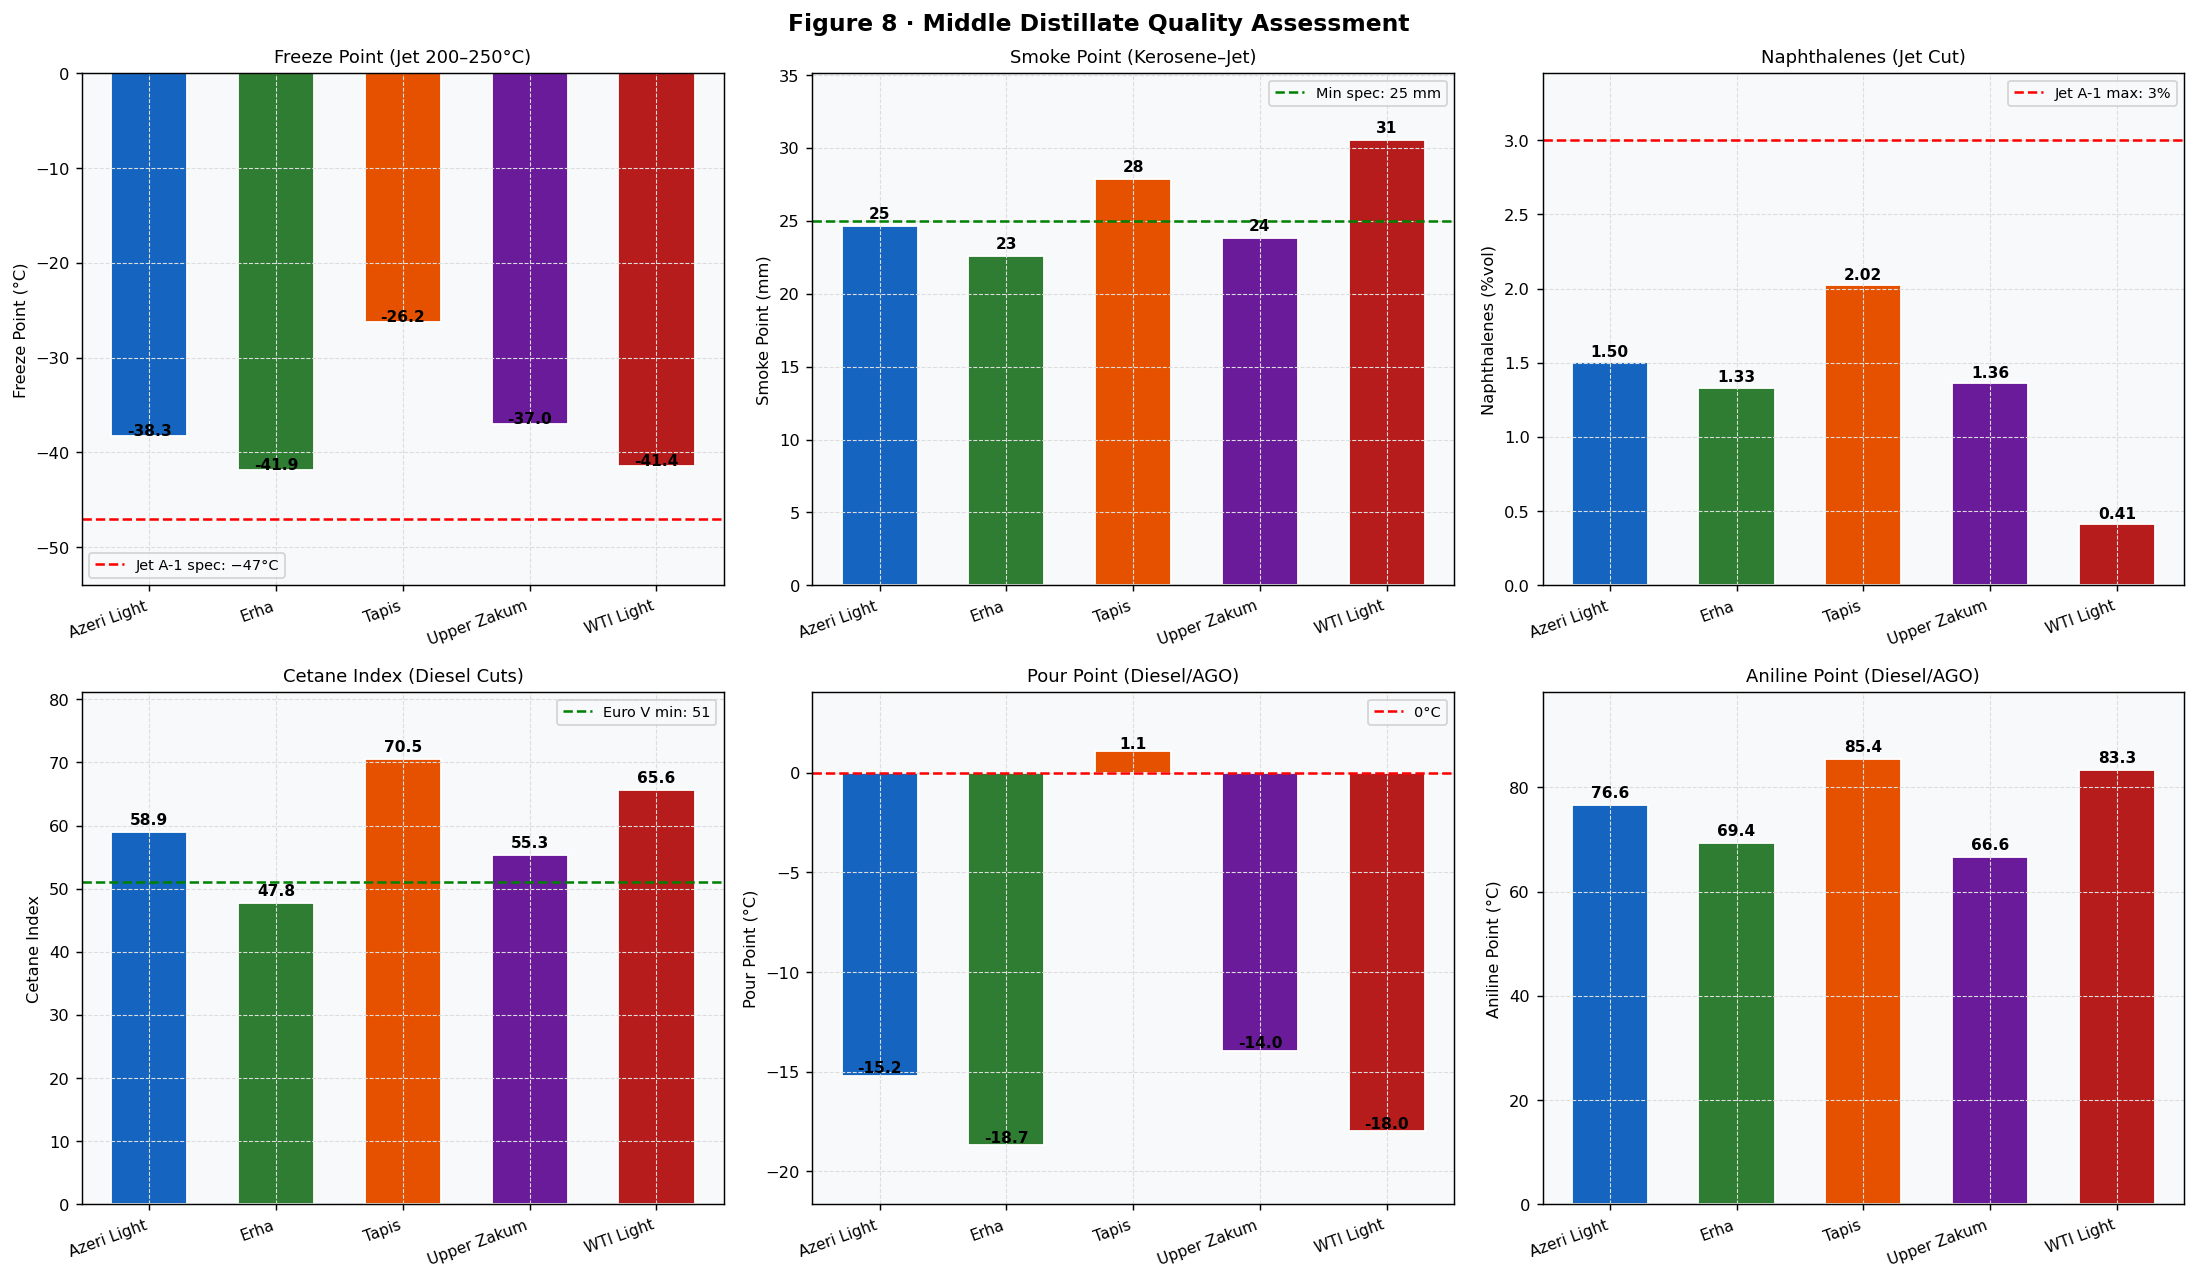


── Middle Distillate Yield (150–370°C), %wt on Crude ──
  Azeri Light          44.3%wt
  Erha                 51.4%wt
  Tapis                49.7%wt
  Upper Zakum          36.4%wt
  WTI Light            43.3%wt

• Total middle distillate yield ranking: ['Erha', 'Tapis', 'Azeri Light', 'WTI Light', 'Upper Zakum']


In [26]:
fig, axes = plt.subplots(2, 3, figsize=(17, 10))
fig.suptitle('Figure 8 · Middle Distillate Quality Assessment', fontsize=13, fontweight='bold')

def plot_cut_bar(ax, prop_key, cut_filter_keys, title, ylabel, fmt='.1f', 
                 threshold=None, thr_label='', thr_color='red', thr_good_above=True):
    """Bar chart for a property across crudes, for cuts matching any filter key."""
    prop_df = get_cut_series(assays, prop_key)
    matched_cols = [c for c in prop_df.columns if any(k in c for k in cut_filter_keys)]
    vals = {}
    for cn in CRUDE_NAMES:
        if cn not in prop_df.index:
            vals[cn] = np.nan; continue
        sub = prop_df.loc[cn, matched_cols].dropna()
        vals[cn] = sub.mean() if len(sub) > 0 else np.nan
    
    series = pd.Series(vals).dropna()
    if series.empty:
        ax.set_title(f'{title}\n(no data)'); return
    
    bar_colors = [CRUDE_COLORS[cn] for cn in series.index]
    bars = ax.bar(range(len(series)), series.values, color=bar_colors, edgecolor='white', width=0.6)
    if threshold is not None:
        ax.axhline(threshold, color=thr_color, ls='--', lw=1.4, label=thr_label)
        ax.legend(fontsize=8)
    for bar, val in zip(bars, series.values):
        ax.text(bar.get_x() + bar.get_width()/2, val + (max(series)*0.01),
                format(val, fmt), ha='center', va='bottom', fontsize=8.5, fontweight='bold')
    ax.set_title(title, fontsize=10)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.set_xticks(range(len(series)))
    ax.set_xticklabels(series.index, rotation=20, ha='right', fontsize=8.5)
    ax.margins(y=0.15)

# Row 1: Jet Fuel Properties 
jet_keys  = ['200-250', '200.0-250', '150-200', '150.0-200']
jet2_keys = ['200-250', '200.0-250']

plot_cut_bar(axes[0, 0], 'Freeze Point (°C)',       jet2_keys, 'Freeze Point (Jet 200–250°C)', 'Freeze Point (°C)',
             fmt='.1f', threshold=-47, thr_label='Jet A-1 spec: −47°C', thr_color='red', thr_good_above=False)

plot_cut_bar(axes[0, 1], 'Smoke Point (mm)',         jet_keys,  'Smoke Point (Kerosene–Jet)', 'Smoke Point (mm)',
             fmt='.0f', threshold=25, thr_label='Min spec: 25 mm', thr_color='green', thr_good_above=True)

plot_cut_bar(axes[0, 2], 'Naphthalenes (% vol)',     jet_keys,  'Naphthalenes (Jet Cut)',     'Naphthalenes (%vol)',
             fmt='.2f', threshold=3.0, thr_label='Jet A-1 max: 3%', thr_color='red')

# Row 2: Diesel Properties 
diesel_keys  = ['250-300', '250.0-300', '300-350', '300.0-350']
diesel_keys2 = ['200-250', '200.0-250', '250-300', '250.0-300', '300-350', '300.0-350', '350-370', '350.0-370']

plot_cut_bar(axes[1, 0], 'Cetane Index (D4737A)', diesel_keys,  'Cetane Index (Diesel Cuts)', 'Cetane Index',
             fmt='.1f', threshold=51, thr_label='Euro V min: 51', thr_color='green')

plot_cut_bar(axes[1, 1], 'Pour Point (°C)',        diesel_keys2,'Pour Point (Diesel/AGO)',   'Pour Point (°C)',
             fmt='.1f', threshold=0, thr_label='0°C')

plot_cut_bar(axes[1, 2], 'Aniline Point (°C)',     diesel_keys2,'Aniline Point (Diesel/AGO)','Aniline Point (°C)',
             fmt='.1f')

fig.tight_layout()
plt.show()

# Middle Distillate Yield Summary
print("\n── Middle Distillate Yield (150–370°C), %wt on Crude ──")
yield_df   = get_cut_series(assays, 'Yield (% wt)')
md_cuts    = [c for c in yield_df.columns if any(k in c for k in
              ['150-', '150.0-', '200-', '200.0-', '250-', '250.0-', '300-', '300.0-', '350-', '350.0-'])]
md_yield   = yield_df[md_cuts].sum(axis=1)
for cn, v in md_yield.items():
    print(f"  {cn:<20} {v:.1f}%wt")
print(f"\n• Total middle distillate yield ranking: {md_yield.sort_values(ascending=False).index.tolist()}")


Key Observations:

• Freeze Point: All 5 crudes meet the Jet A-1 freeze point spec (≤ −47°C) in the 200–250°C cut.

• Smoke Point: Tapis and WTI Light jet cuts have the highest smoke points, indicating low aromatic content. Azeri Light is lower due to higher aromatics.

• Cetane Index: All crudes produce Diesel/AGO meeting Euro V Cetane spec (>51) in the 250–350°C range, with Tapis and WTI Light diesel excelling.

• Pour Point: Heavier diesel cuts (300–370°C) from Erha and Azeri Light show high pour points, requiring flow improvers in cold climates.

• Aniline Point: Higher aniline point in WTI Light and Upper Zakum diesel/AGO fractions — these have lower aromatic content, better seal compatibility.

---
## Section 6 — Vacuum Gas Oil, Atmospheric Residue & Heavy Ends

The heavy end products dictate refinery conversion unit performance:
- **VGO (370–550°C)**: Primary feed to FCC (Fluid Catalytic Cracker) and Hydrocracker units
- **Vacuum Residue (550°C+)**: Feed to Coker, Solvent Deasphalting, Visbreaker, or used as fuel oil
- **Micro Carbon Residue (MCR)**: Indicates propensity to form coke — critical FCC catalyst deactivation driver
- **C7 Asphaltenes**: Heavy polar molecules that foul equipment and catalysts
- **Vanadium + Nickel**: Metal contaminants that permanently poison FCC catalyst; V also causes cyclone erosion

#### Heavy Ends — VGO, Residue MCR, Metals & Asphaltenes

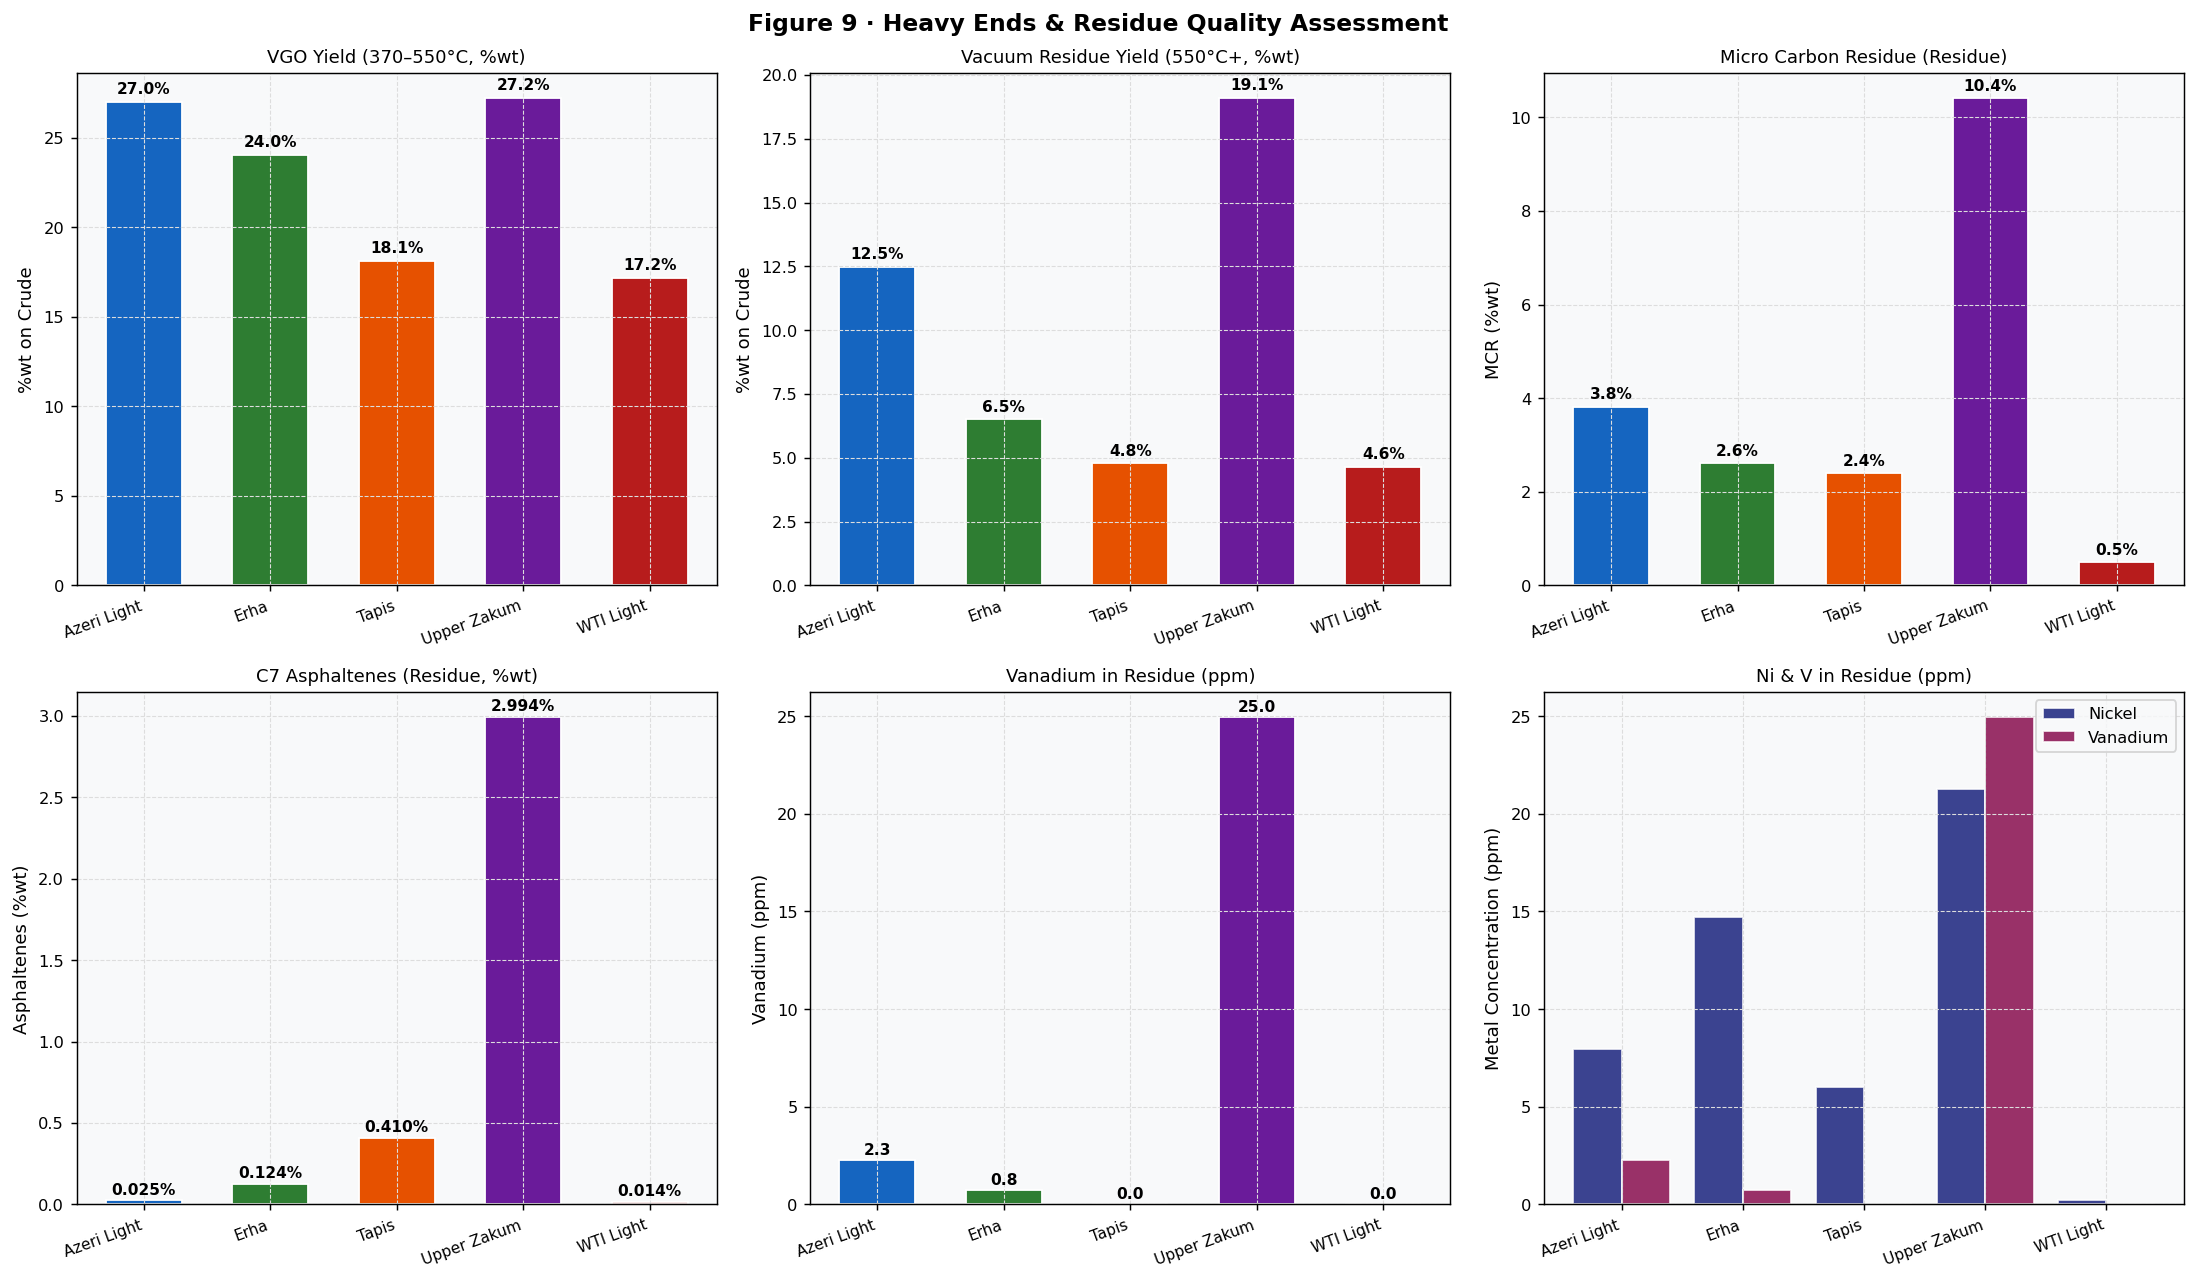

In [28]:
fig, axes = plt.subplots(2, 3, figsize=(17, 10))
fig.suptitle('Figure 9 · Heavy Ends & Residue Quality Assessment', fontsize=13, fontweight='bold')

# Helper
def get_residue_vals(prop_key, cut_keys):
    df = get_cut_series(assays, prop_key)
    result = {}
    for cn in CRUDE_NAMES:
        if cn not in df.index:
            result[cn] = np.nan; continue
        matched = [c for c in cut_keys if c in df.columns]
        if matched:
            vals = df.loc[cn, matched].dropna()
            result[cn] = vals.iloc[0] if len(vals) > 0 else np.nan
        else:
            result[cn] = np.nan
    return pd.Series(result)

residue_raw = ['370-FBP', '370.0-FBP']
vac_res_raw = ['550-FBP', '550.0-FBP']
lvgo_raw    = ['370-450', '370.0-450.0']

# Panel A: VGO Yield
ax = axes[0, 0]
yield_df = get_cut_series(assays, 'Yield (% wt)')
vgo_cuts = [c for c in yield_df.columns if any(k in c for k in
            ['370-450', '370.0-450', '450-500', '450.0-500', '500-550', '500.0-550'])]
vgo_yield = yield_df[vgo_cuts].sum(axis=1)
bars = ax.bar(range(len(CRUDE_NAMES)), [vgo_yield.get(cn, 0) for cn in CRUDE_NAMES],
              color=PALETTE, edgecolor='white', width=0.6)
for bar, cn in zip(bars, CRUDE_NAMES):
    v = vgo_yield.get(cn, 0)
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.3, f'{v:.1f}%',
            ha='center', va='bottom', fontsize=8.5, fontweight='bold')
ax.set_title('VGO Yield (370–550°C, %wt)', fontsize=10)
ax.set_ylabel('%wt on Crude')
ax.set_xticks(range(len(CRUDE_NAMES)))
ax.set_xticklabels(CRUDE_NAMES, rotation=20, ha='right', fontsize=8.5)

# Panel B: Vacuum Residue Yield
ax = axes[0, 1]
vac_res_yield = get_residue_vals('Yield (% wt)', vac_res_raw)
bars = ax.bar(range(len(CRUDE_NAMES)), [vac_res_yield.get(cn, np.nan) for cn in CRUDE_NAMES],
              color=PALETTE, edgecolor='white', width=0.6)
for bar, cn in zip(bars, CRUDE_NAMES):
    v = vac_res_yield.get(cn, np.nan)
    if not np.isnan(v):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.2, f'{v:.1f}%',
                ha='center', va='bottom', fontsize=8.5, fontweight='bold')
ax.set_title('Vacuum Residue Yield (550°C+, %wt)', fontsize=10)
ax.set_ylabel('%wt on Crude')
ax.set_xticks(range(len(CRUDE_NAMES)))
ax.set_xticklabels(CRUDE_NAMES, rotation=20, ha='right', fontsize=8.5)

# Panel C: MCR in Residue
ax = axes[0, 2]
mcr_df = get_cut_series(assays, 'Micro Carbon Residue (% wt)')
mcr_res = {}
for cn in CRUDE_NAMES:
    if cn not in mcr_df.index:
        mcr_res[cn] = np.nan; continue
    row = mcr_df.loc[cn]
    # Using vacuum residue or atm residue MCR
    opts = [c for c in row.index if any(k in c for k in ['550-FBP', '550.0-FBP', '370-FBP', '370.0-FBP'])]
    vals = row[opts].dropna()
    mcr_res[cn] = vals.iloc[0] if len(vals) > 0 else np.nan
mcr_series = pd.Series(mcr_res).dropna()
bars = ax.bar(range(len(mcr_series)), mcr_series.values,
              color=[CRUDE_COLORS[cn] for cn in mcr_series.index], edgecolor='white', width=0.6)
for bar, val in zip(bars, mcr_series.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.1, f'{val:.1f}%',
            ha='center', va='bottom', fontsize=8.5, fontweight='bold')
ax.set_title('Micro Carbon Residue (Residue)', fontsize=10)
ax.set_ylabel('MCR (%wt)')
ax.set_xticks(range(len(mcr_series)))
ax.set_xticklabels(mcr_series.index, rotation=20, ha='right', fontsize=8.5)

# Panel D: C7 Asphaltenes (Residue)
ax = axes[1, 0]
asp_df = get_cut_series(assays, 'C7 Asphaltenes (% wt)')
asp_res = {}
for cn in CRUDE_NAMES:
    if cn not in asp_df.index:
        asp_res[cn] = np.nan; continue
    row = asp_df.loc[cn]
    opts = [c for c in row.index if any(k in c for k in ['550-FBP', '550.0-FBP', '370-FBP', '370.0-FBP'])]
    vals = row[opts].dropna()
    asp_res[cn] = vals.iloc[0] if len(vals) > 0 else np.nan
asp_series = pd.Series(asp_res).dropna()
bars = ax.bar(range(len(asp_series)), asp_series.values,
              color=[CRUDE_COLORS[cn] for cn in asp_series.index], edgecolor='white', width=0.6)
for bar, val in zip(bars, asp_series.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.02, f'{val:.3f}%',
            ha='center', va='bottom', fontsize=8.5, fontweight='bold')
ax.set_title('C7 Asphaltenes (Residue, %wt)', fontsize=10)
ax.set_ylabel('Asphaltenes (%wt)')
ax.set_xticks(range(len(asp_series)))
ax.set_xticklabels(asp_series.index, rotation=20, ha='right', fontsize=8.5)

# Panel E: Vanadium in Residue
ax = axes[1, 1]
van_df = get_cut_series(assays, 'Vanadium (ppm)')
van_res = {}
for cn in CRUDE_NAMES:
    if cn not in van_df.index:
        van_res[cn] = np.nan; continue
    row = van_df.loc[cn]
    opts = [c for c in row.index if any(k in c for k in ['550-FBP', '550.0-FBP', '370-FBP', '370.0-FBP'])]
    vals = row[opts].dropna()
    van_res[cn] = vals.iloc[0] if len(vals) > 0 else np.nan
van_series = pd.Series(van_res).dropna()
bars = ax.bar(range(len(van_series)), van_series.values,
              color=[CRUDE_COLORS[cn] for cn in van_series.index], edgecolor='white', width=0.6)
for bar, val in zip(bars, van_series.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.1, f'{val:.1f}',
            ha='center', va='bottom', fontsize=8.5, fontweight='bold')
ax.set_title('Vanadium in Residue (ppm)', fontsize=10)
ax.set_ylabel('Vanadium (ppm)')
ax.set_xticks(range(len(van_series)))
ax.set_xticklabels(van_series.index, rotation=20, ha='right', fontsize=8.5)

# Panel F: Ni+V Metals in Residue (combined)
ax = axes[1, 2]
nik_df = get_cut_series(assays, 'Nickel (ppm)')
ni_res  = {}
for cn in CRUDE_NAMES:
    ni_res[cn] = np.nan
    if cn not in nik_df.index:
        continue
    row = nik_df.loc[cn]
    opts = [c for c in row.index if any(k in c for k in ['550-FBP', '550.0-FBP', '370-FBP', '370.0-FBP'])]
    vals = row[opts].dropna()
    if len(vals) > 0:
        ni_res[cn] = vals.iloc[0]

ni_series  = pd.Series(ni_res).reindex(CRUDE_NAMES)
van_series2 = pd.Series(van_res).reindex(CRUDE_NAMES)

x = np.arange(len(CRUDE_NAMES))
w = 0.4
ax.bar(x - w/2, [ni_series.get(cn, 0) for cn in CRUDE_NAMES],  w, color='#1A237E', alpha=0.85, label='Nickel',   edgecolor='white')
ax.bar(x + w/2, [van_series2.get(cn, 0) for cn in CRUDE_NAMES], w, color='#880E4F', alpha=0.85, label='Vanadium', edgecolor='white')
ax.set_title('Ni & V in Residue (ppm)', fontsize=10)
ax.set_ylabel('Metal Concentration (ppm)')
ax.set_xticks(x)
ax.set_xticklabels(CRUDE_NAMES, rotation=20, ha='right', fontsize=8.5)
ax.legend(fontsize=9)

fig.tight_layout()
plt.show()


Key Observations:

• VGO Yield: Azeri Light has the highest VGO yield including LVGO/MVGO/HVGO (combined ~27%wt), very attractive for FCC-focused refinery.

• Vacuum Residue: Upper Zakum has the highest vacuum residue yield (~19%wt) — significant bottom-of-barrel challenge.

• MCR: Upper Zakum's residue has the highest MCR (~15–20%), meaning more coke formation in FCC and coker.

  Tapis residue has notably low MCR, making it a much cleaner FCC/hydrocracker feed.

• Asphaltenes: Most crudes have very low asphaltene content in residue. Erha residue has notable asphaltenes.

• Metals (Ni+V): Upper Zakum residue is highest in V+Ni — must be demetallised before FCC processing.

  Tapis and WTI Light residues are essentially metal-free — premium FCC feed quality.

---
## Section 7 — Molecular & PNA Composition

This section analyses the **light hydrocarbon molecular breakdown** (C1–C7) and the **Paraffins/Naphthenes/Aromatics (PNA) profile** across the full distillation range.

The PNA composition is fundamental to:
- **Naphtha**: Determines reformer hydrogen production and aromatic potential
- **Diesel/AGO**: Paraffinic diesels have higher Cetane; naphthenic ones have lower cloud/pour points
- **H₂ content**: High paraffin content = higher hydrogen per molecule = premium refinery value

#### Light Hydrocarbon Molecule Composition

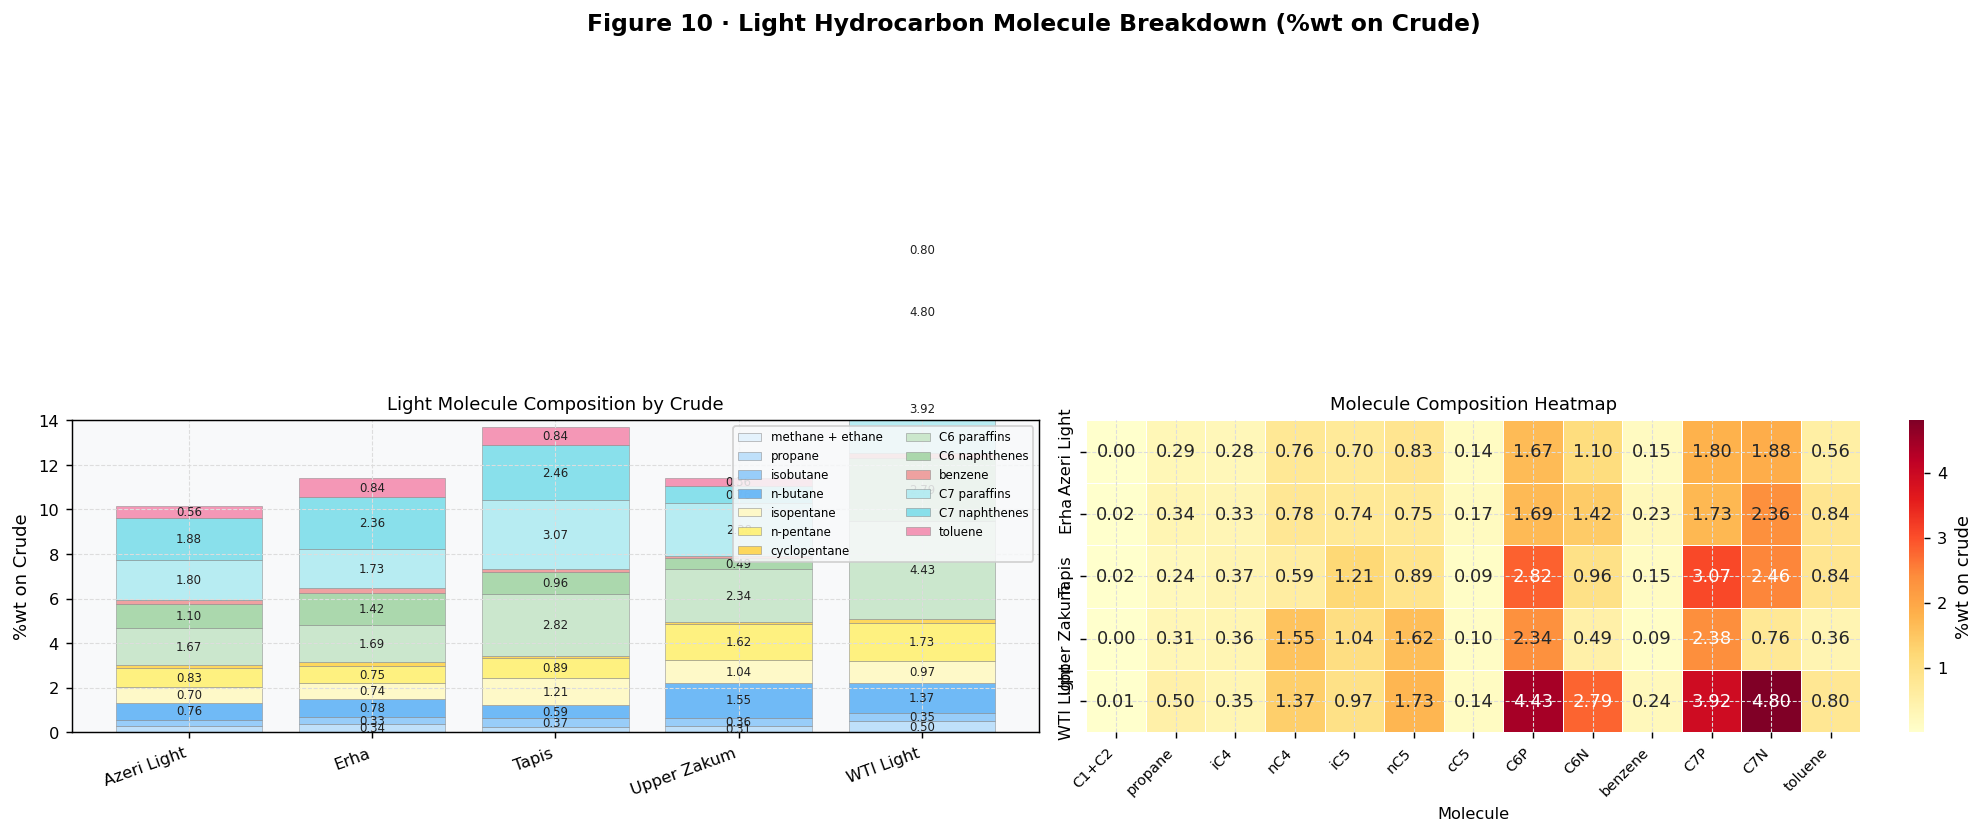

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6.5))
fig.suptitle('Figure 10 · Light Hydrocarbon Molecule Breakdown (%wt on Crude)', fontsize=13, fontweight='bold')

# Building molecule data
mol_data = {}
for cn in CRUDE_NAMES:
    mol_data[cn] = assays[cn]['molecules']

# Molecule order (lightest to heaviest)
mol_order = [
    'methane + ethane', 'propane', 'isobutane', 'n-butane',
    'isopentane', 'n-pentane', 'cyclopentane',
    'C6 paraffins', 'C6 naphthenes', 'benzene',
    'C7 paraffins', 'C7 naphthenes', 'toluene'
]
mol_colors = [
    '#E3F2FD', '#BBDEFB', '#90CAF9', '#64B5F6',
    '#FFF9C4', '#FFF176', '#FFD54F',
    '#C8E6C9', '#A5D6A7', '#EF9A9A',
    '#B2EBF2', '#80DEEA', '#F48FB1'
]

# Panel A: Stacked bar chart
ax = axes[0]
x = np.arange(len(CRUDE_NAMES))
bottoms = np.zeros(len(CRUDE_NAMES))
for mol, color in zip(mol_order, mol_colors):
    vals = [mol_data[cn].get(mol, np.nan) for cn in CRUDE_NAMES]
    valid_vals = [v if not np.isnan(v) else 0 for v in vals]
    bars = ax.bar(x, valid_vals, bottom=bottoms, label=mol, color=color,
                  edgecolor='#888888', linewidth=0.3, alpha=0.92)
    for i, (bar, v) in enumerate(zip(bars, valid_vals)):
        if v > 0.3:
            ax.text(bar.get_x() + bar.get_width()/2, bottoms[i] + v/2,
                    f'{v:.2f}', ha='center', va='center', fontsize=6.5, color='#212121')
    bottoms += np.array(valid_vals)

ax.set_title('Light Molecule Composition by Crude', fontsize=10)
ax.set_ylabel('%wt on Crude')
ax.set_xticks(x)
ax.set_xticklabels(CRUDE_NAMES, rotation=20, ha='right', fontsize=9)
ax.legend(loc='upper right', fontsize=6.5, framealpha=0.85, ncol=2, bbox_to_anchor=(1.0, 1.0))
ax.set_ylim(0, 14)

# Panel B: Heatmap of molecules
ax = axes[1]
mol_df = pd.DataFrame({mol: [mol_data[cn].get(mol, np.nan) for cn in CRUDE_NAMES] for mol in mol_order},
                       index=CRUDE_NAMES)
mol_display = mol_df.copy()
# Renaming molecules for display
mol_display.columns = [m.replace('methane + ethane', 'C1+C2').replace('isobutane', 'iC4').replace('n-butane', 'nC4')
                        .replace('isopentane', 'iC5').replace('n-pentane', 'nC5').replace('cyclopentane', 'cC5')
                        .replace('C6 paraffins', 'C6P').replace('C6 naphthenes', 'C6N')
                        .replace('C7 paraffins', 'C7P').replace('C7 naphthenes', 'C7N')
                        for m in mol_display.columns]

sns.heatmap(mol_display, annot=True, fmt='.2f', cmap='YlOrRd', linewidths=0.4,
            linecolor='white', ax=ax, cbar_kws={'label': '%wt on crude'})
ax.set_title('Molecule Composition Heatmap', fontsize=10)
ax.set_ylabel('')
ax.set_xlabel('Molecule', fontsize=9)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)

fig.tight_layout()
plt.show()


Key Observations:

• WTI Light and Tapis have the highest total light molecule content (C1–C7), consistent with their high API and RVP.

• n-butane and isobutane: WTI Light leads — this crude is richest in LPG-range components.

• Erha has the lowest C1-C7 content, suggesting most hydrocarbons are in the mid-range cuts.

• Benzene and toluene: Azeri Light and Erha show slightly more aromatics in the light ends.

• Topis has significantly higher n-pentane and isopentane — important for gasoline blending and NGL processing.

#### PNA Composition Across Cuts (Heatmaps) + H₂ Content

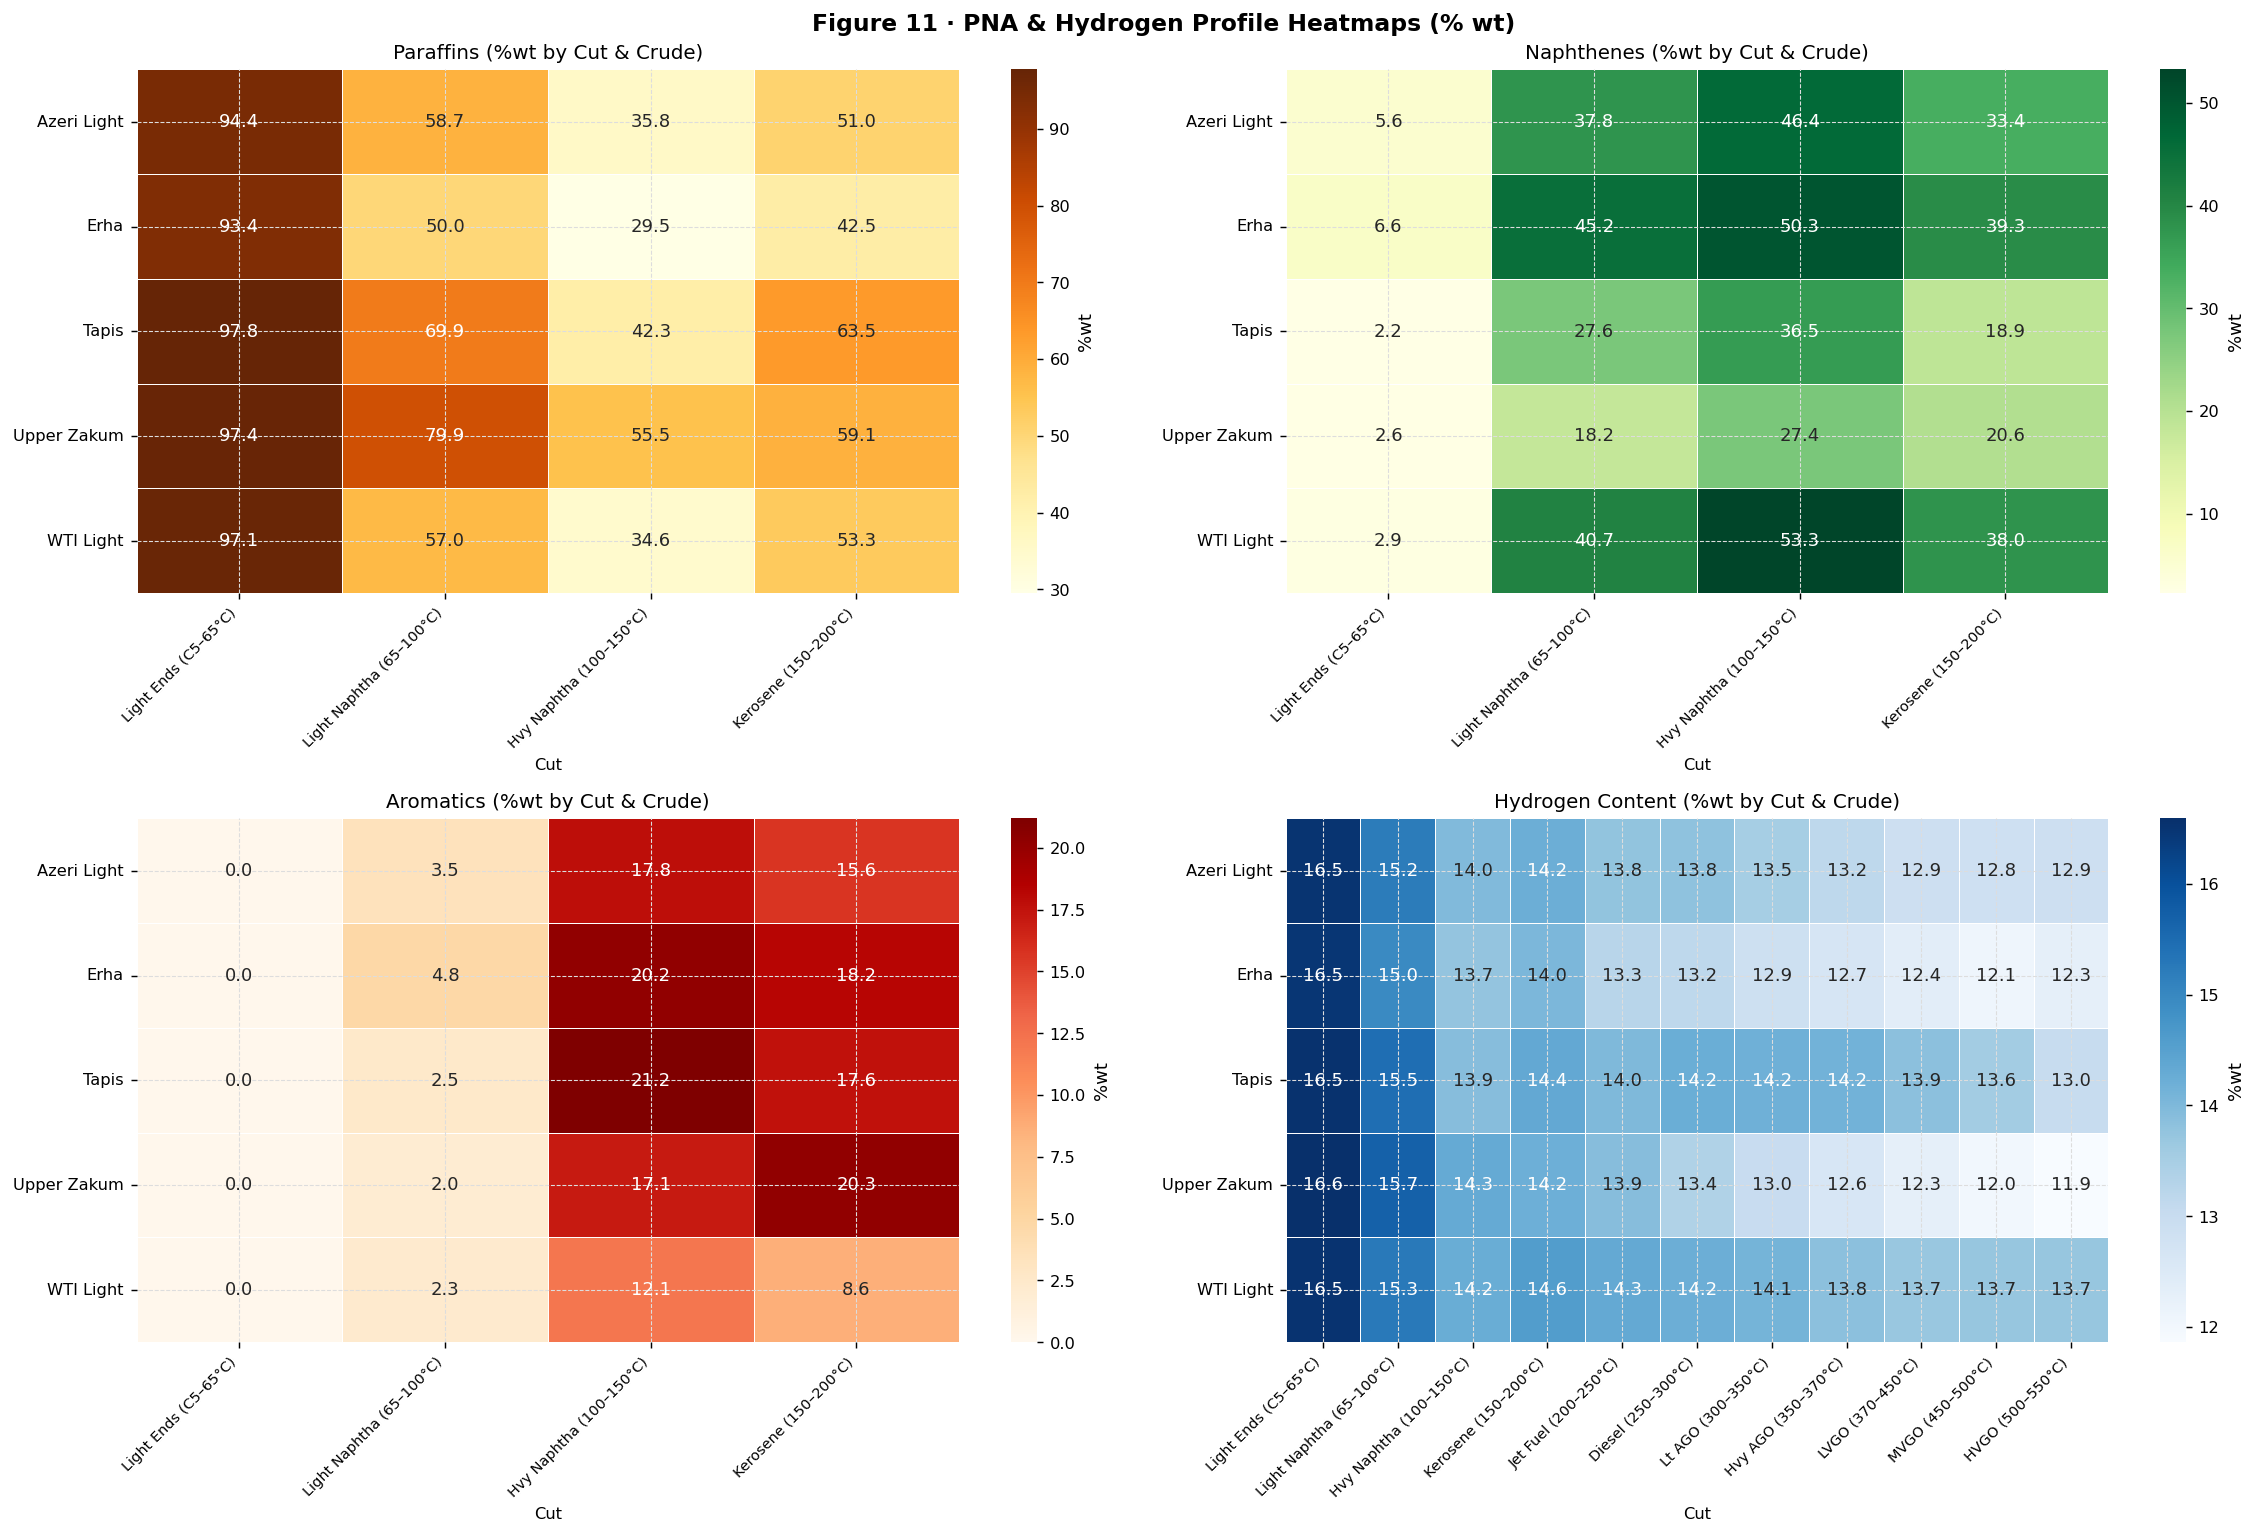

In [30]:
par_df = get_cut_series(assays, 'Paraffins (% wt)')
nap_df = get_cut_series(assays, 'Naphthenes (%wt)')
aro_df = get_cut_series(assays, 'Aromatics (% wt)')
h2_df  = get_cut_series(assays, 'Hydrogen (% wt)')

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Figure 11 · PNA & Hydrogen Profile Heatmaps (% wt)', fontsize=13, fontweight='bold')

pna_data_sets = [
    (par_df, axes[0, 0], 'Paraffins (%wt by Cut & Crude)', 'YlOrBr'),
    (nap_df, axes[0, 1], 'Naphthenes (%wt by Cut & Crude)', 'YlGn'),
    (aro_df, axes[1, 0], 'Aromatics (%wt by Cut & Crude)', 'OrRd'),
    (h2_df,  axes[1, 1], 'Hydrogen Content (%wt by Cut & Crude)', 'Blues'),
]

def pna_col_rename(cols):
    return [CUT_FRIENDLY.get(c, c).replace('\n', ' ') for c in cols]

for df_in, ax, title, cmap in pna_data_sets:
    # Filter to light–middle fraction cuts only (skip residues for clarity)
    valid_cuts = [c for c in df_in.columns if
                  not any(k in c for k in ['370-FBP', '370.0-FBP']) and
                  not df_in[[c]].isna().all().all()]
    if not valid_cuts:
        ax.set_title(f'{title}\n(insufficient data)'); continue
    plot_data   = df_in[valid_cuts].dropna(how='all', axis=1).dropna(how='all', axis=0)
    if plot_data.empty:
        ax.set_title(f'{title}\n(insufficient data)'); continue
    col_names   = pna_col_rename(plot_data.columns)
    sns.heatmap(plot_data, annot=True, fmt='.1f', cmap=cmap,
                linewidths=0.4, linecolor='white', ax=ax,
                xticklabels=col_names, yticklabels=plot_data.index,
                cbar_kws={'label': '%wt'})
    ax.set_title(title, fontsize=11)
    ax.set_ylabel('')
    ax.set_xlabel('Cut', fontsize=9)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)

fig.tight_layout()
plt.show()


Key Observations (PNA Across Cuts):

• Paraffins: Light ends (C5-100°C) are highly paraffinic for all crudes. WTI Light and Tapis maintain higher paraffin content even in heavier naphtha cuts.

• Naphthenes: Azeri Light and Erha show the highest naphthene content in naphtha range — excellent rings for catalytic reforming to form aromatics.

• Aromatics: Aromatics are minimal in light naphtha but increase in heavier naphtha. The heaviest aromatics concentrate in the 150-200°C range (benzene ring compounds).

• Hydrogen: Lighter cuts have more hydrogen (%wt), as expected. WTI Light and Tapis have consistently higher hydrogen content across cuts — higher hydrogen-rich value.

• Upper Zakum shows lower paraffin content in naphtha range, reflecting its more naphthenic/aromatic character despite being a UAE light crude.

---
## Section 8 — Key Inferences, Rankings & Refinery Suitability Assessment

This final section synthesises all findings into:
1. **Ranked comparison tables** across key crude metrics
2. **Spider / Radar chart** for visual holistic comparison
3. **Refinery application suitability matrix**
4. **Summary of strengths and weaknesses** for each crude

#### Ranked Comparison Table

In [ ]:

# Reloading yield_df in case not available from prior scope
yield_df = get_cut_series(assays, 'Yield (% wt)')

def safe_get(key):
    s = get_whole_prop(assays, key)
    return {cn: (s[cn] if cn in s and not np.isnan(s[cn]) else np.nan) for cn in CRUDE_NAMES}

metrics = {
    'API Gravity (°)':           safe_get('API Gravity'),
    'Total Sulfur (%wt)':        safe_get('Total Sulfur (% wt)'),
    'TAN (mgKOH/g)':             safe_get('Total Acid Number (mgKOH/g)'),
    'Vanadium (ppm)':            safe_get('Vanadium (ppm)'),
    'Nickel (ppm)':              safe_get('Nickel (ppm)'),
    'Total Nitrogen (ppm)':      safe_get('Total Nitrogen (ppm)'),
    'Viscosity @40°C (cSt)':     safe_get('Viscosity @ 40°C (cSt)'),
    'RVP (kPa)':                 safe_get('Reid Vapor Pressure (kPa)'),
    'Pour Point (°C)':           safe_get('Pour Point (°C)'),
}

# Yield-based metrics
naphtha_cuts = [c for c in yield_df.columns if any(k in str(c) for k in ['C5','65-','65.0-','100-','100.0-'])]
md_cuts      = [c for c in yield_df.columns if any(k in str(c) for k in ['150-','150.0-','200-','200.0-','250-','250.0-','300-','300.0-','350-','350.0-'])]
vgo_cuts     = [c for c in yield_df.columns if any(k in str(c) for k in ['370-450','370.0-450','450-500','450.0-500','500-550','500.0-550'])]

for cn in CRUDE_NAMES:
    metrics.setdefault('Naphtha Yield (%wt)', {})[cn]  = yield_df.loc[cn, naphtha_cuts].sum() if cn in yield_df.index else np.nan
    metrics.setdefault('Mid-Dist Yield (%wt)', {})[cn] = yield_df.loc[cn, md_cuts].sum()      if cn in yield_df.index else np.nan
    metrics.setdefault('VGO Yield (%wt)', {})[cn]      = yield_df.loc[cn, vgo_cuts].sum()     if cn in yield_df.index else np.nan

metrics['Naphtha Yield (%wt)']  = {cn: yield_df.loc[cn, naphtha_cuts].sum() if cn in yield_df.index else np.nan for cn in CRUDE_NAMES}
metrics['Mid-Dist Yield (%wt)'] = {cn: yield_df.loc[cn, md_cuts].sum()      if cn in yield_df.index else np.nan for cn in CRUDE_NAMES}
metrics['VGO Yield (%wt)']      = {cn: yield_df.loc[cn, vgo_cuts].sum()     if cn in yield_df.index else np.nan for cn in CRUDE_NAMES}

ci_df   = get_cut_series(assays, 'Cetane Index (D4737A)')
ci_cuts = [c for c in ci_df.columns if any(k in str(c) for k in ['250-300','250.0-300'])]
metrics['Cetane Index (diesel)'] = {cn: (ci_df.loc[cn, ci_cuts].mean() if cn in ci_df.index and ci_cuts else np.nan) for cn in CRUDE_NAMES}

rank_df = pd.DataFrame(metrics).T[CRUDE_NAMES]

fmt_map = {
    'API Gravity (°)': '.1f',     'Total Sulfur (%wt)': '.3f',  'TAN (mgKOH/g)': '.3f',
    'Vanadium (ppm)': '.2f',      'Nickel (ppm)': '.2f',         'Total Nitrogen (ppm)': '.0f',
    'Viscosity @40°C (cSt)': '.2f','RVP (kPa)': '.1f',           'Pour Point (°C)': '.1f',
    'Naphtha Yield (%wt)': '.1f', 'Mid-Dist Yield (%wt)': '.1f','VGO Yield (%wt)': '.1f',
    'Cetane Index (diesel)': '.1f',
}

# Building display DataFrame with object dtype to hold formatted strings
rank_display = pd.DataFrame(index=rank_df.index, columns=rank_df.columns, dtype=object)
for idx in rank_df.index:
    fmt = fmt_map.get(str(idx), '.2f')
    for col in rank_df.columns:
        v = rank_df.loc[idx, col]
        try:
            fv = float(v)
            rank_display.loc[idx, col] = '—' if np.isnan(fv) else format(fv, fmt)
        except Exception:
            rank_display.loc[idx, col] = str(v)

# Highlighting best/worst per row
def rank_highlight(s):
    vals = []
    for v in s:
        try:    vals.append(float(str(v).replace('—', 'nan')))
        except: vals.append(np.nan)
    arr = np.array(vals, dtype=float)
    if np.all(np.isnan(arr)):
        return [''] * len(s)
    higher_better = str(s.name) in [
        'API Gravity (°)', 'Naphtha Yield (%wt)', 'Mid-Dist Yield (%wt)',
        'VGO Yield (%wt)', 'Cetane Index (diesel)', 'RVP (kPa)'
    ]
    best_idx  = int(np.nanargmax(arr)) if higher_better else int(np.nanargmin(arr))
    worst_idx = int(np.nanargmin(arr)) if higher_better else int(np.nanargmax(arr))
    styles = ['' for _ in arr]
    styles[best_idx]  = 'background-color: #C8E6C9; font-weight: bold'
    styles[worst_idx] = 'background-color: #FFCDD2; font-weight: bold'
    return styles

print("Table 3 · Comprehensive Crude Ranking Matrix\n")
try:
    styled_rank = (rank_display.style
        .set_caption('Table 3 · Key Crude Properties & Yield Ranking  (green = best, red = worst per row)')
        .apply(rank_highlight, axis=1)
        .set_table_styles([
            {'selector': 'caption', 'props': [('font-size','13px'),('font-weight','bold'),('padding-bottom','8px')]},
            {'selector': 'th',      'props': [('background-color','#263238'),('color','white'),('font-size','11px'),('padding','6px 10px')]},
            {'selector': 'td',      'props': [('text-align','center'),('padding','5px 12px'),('font-size','11px')]},
            {'selector': 'tr:nth-child(even)', 'props': [('background-color','#ECEFF1')]},
        ])
    )
    display(styled_rank)
except Exception as e:
    print(rank_display.to_string())
    print(f"Styling error: {e}")


Table 3 · Comprehensive Crude Ranking Matrix



,Azeri Light,Erha,Tapis,Upper Zakum,WTI Light
API Gravity (°),35.6,35.1,45.8,33.1,47.5
Total Sulfur (%wt),0.185,0.179,0.033,2.070,0.046
TAN (mgKOH/g),0.482,0.329,0.206,0.074,0.074
Vanadium (ppm),0.90,0.23,0.01,11.57,0.01
Nickel (ppm),3.15,4.49,1.38,9.86,0.04
Total Nitrogen (ppm),1057,792,221,863,106
Viscosity @40°C (cSt),5.33,3.46,1.89,5.91,1.72
RVP (kPa),35.1,39.6,72.6,59.5,56.3
Pour Point (°C),-19.7,-24.0,2.6,-21.0,-30.2
Naphtha Yield (%wt),15.4,17.0,25.5,15.4,32.7


### Radar Chart — Holistic Crude Comparison

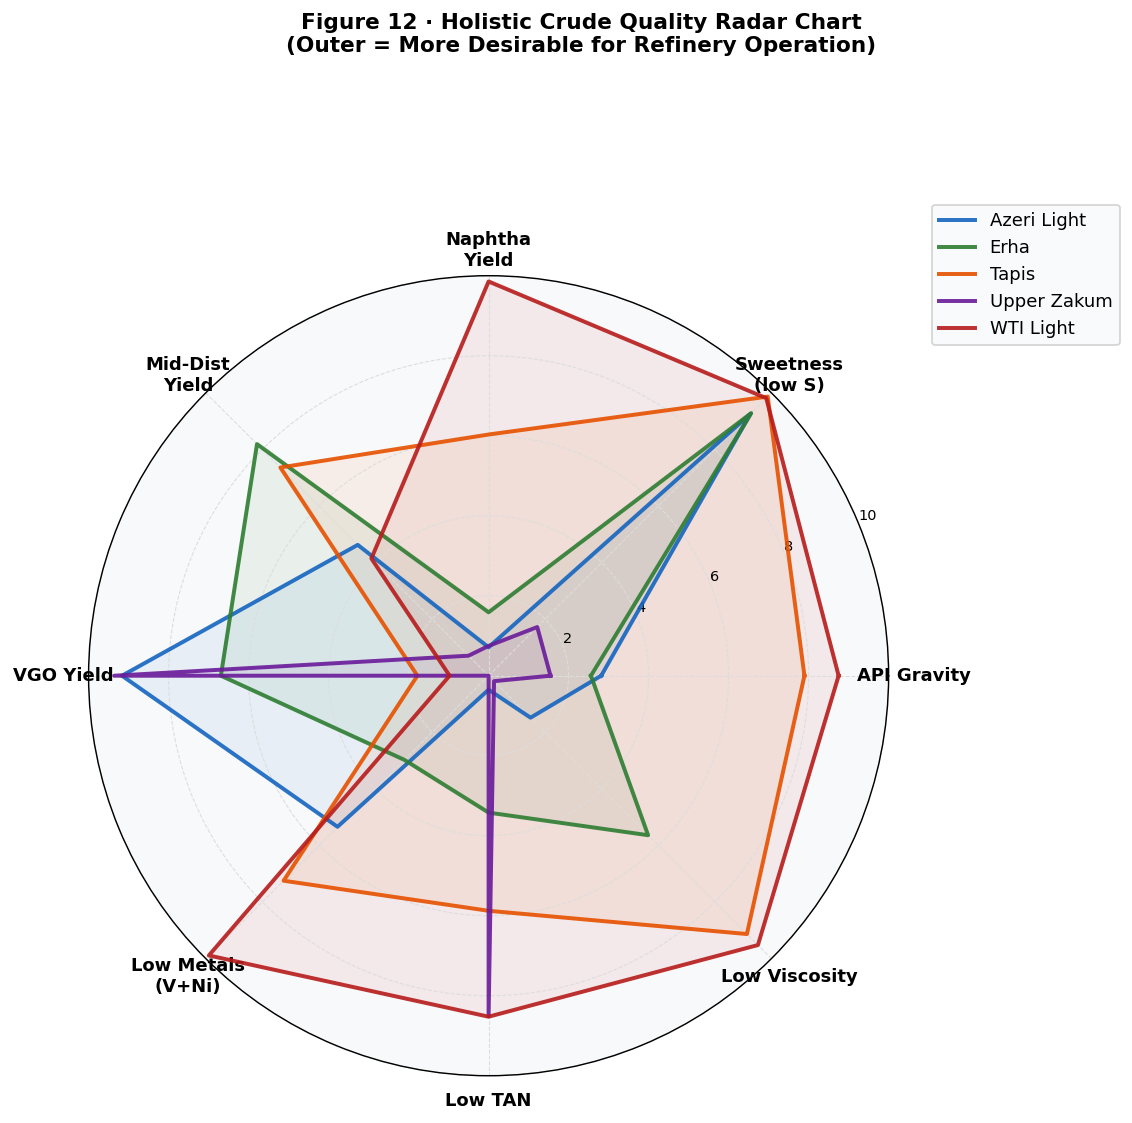

In [ ]:
# Parameters for radar chart (normalised 0–10 scale, higher = better for refinery)
# All dimensions: higher score means more desirable
radar_metrics = {
    'API Gravity':    {'key': 'API Gravity',                  'higher_better': True,  'scale': (30, 50)},
    'Sweetness\n(low S)': {'key': 'Total Sulfur (% wt)',       'higher_better': False, 'scale': (0.0, 2.5)},
    'Naphtha\nYield': {'key': None,                           'higher_better': True,  'scale': (14, 33)},
    'Mid-Dist\nYield':{'key': None,                           'higher_better': True,  'scale': (35, 55)},
    'VGO Yield':      {'key': None,                           'higher_better': True,  'scale': (16, 28)},
    'Low Metals\n(V+Ni)': {'key': None,                       'higher_better': False, 'scale': (0, 22)},
    'Low TAN':        {'key': 'Total Acid Number (mgKOH/g)',  'higher_better': False, 'scale': (0.0, 0.5)},
    'Low Viscosity':  {'key': 'Viscosity @ 40°C (cSt)',       'higher_better': False, 'scale': (1.5, 6.0)},
}

def normalise(val, scale, higher_better):
    lo, hi = scale
    if np.isnan(val): return 5.0
    val = np.clip(val, lo, hi)
    norm = (val - lo) / (hi - lo)   # 0..1
    return (norm * 10) if higher_better else ((1 - norm) * 10)

# Building scores
radar_labels = list(radar_metrics.keys())
N = len(radar_labels)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]  # close polygon

# Pre-computing yield sums
yield_df = get_cut_series(assays, 'Yield (% wt)')
naphtha_cuts = [c for c in yield_df.columns if any(k in c for k in ['C5','65-','65.0-','100-','100.0-'])]
md_cuts      = [c for c in yield_df.columns if any(k in c for k in ['150-','150.0-','200-','200.0-','250-','250.0-','300-','300.0-','350-','350.0-'])]
vgo_cuts     = [c for c in yield_df.columns if any(k in c for k in ['370-450','370.0-450','450-500','450.0-500','500-550','500.0-550'])]
van_df = get_cut_series(assays, 'Vanadium (ppm)')
nik_df = get_cut_series(assays, 'Nickel (ppm)')

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))
fig.suptitle('Figure 12 · Holistic Crude Quality Radar Chart\n(Outer = More Desirable for Refinery Operation)',
             fontsize=12, fontweight='bold', y=1.02)

for crude, color in CRUDE_COLORS.items():
    scores = []
    for label, cfg in radar_metrics.items():
        key   = cfg['key']
        scale = cfg['scale']
        hb    = cfg['higher_better']
        if key is not None:
            v = assays[crude]['whole_crude'].get(key, assays[crude]['gen_props'].get(key, np.nan))
            scores.append(normalise(float(v) if v is not None else np.nan, scale, hb))
        elif label.startswith('Naphtha'):
            v = yield_df.loc[crude, naphtha_cuts].sum() if crude in yield_df.index else np.nan
            scores.append(normalise(v, scale, hb))
        elif label.startswith('Mid-Dist'):
            v = yield_df.loc[crude, md_cuts].sum() if crude in yield_df.index else np.nan
            scores.append(normalise(v, scale, hb))
        elif label.startswith('VGO'):
            v = yield_df.loc[crude, vgo_cuts].sum() if crude in yield_df.index else np.nan
            scores.append(normalise(v, scale, hb))
        elif 'Metals' in label:
            van_v = van_df.loc[crude].dropna().iloc[0] if crude in van_df.index else 0
            ni_v  = nik_df.loc[crude].dropna().iloc[0] if crude in nik_df.index else 0
            scores.append(normalise(float(van_v) + float(ni_v), scale, hb))
        else:
            scores.append(5.0)
    
    scores += scores[:1]  # close
    ax.plot(angles, scores, color=color, lw=2.2, label=crude, alpha=0.9)
    ax.fill(angles, scores, color=color, alpha=0.07)

# Axis settings
ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_labels, fontsize=10, fontweight='bold')
ax.set_yticks([2, 4, 6, 8, 10])
ax.set_yticklabels(['2', '4', '6', '8', '10'], fontsize=8)
ax.set_ylim(0, 10)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=10)

fig.tight_layout()
plt.show()


#### Refinery Suitability Matrix & Final Inferences

In [ ]:
suitability = {
    'Crude': CRUDE_NAMES,
    'Classification': ['Light Sweet', 'Light Sweet', 'Light Ultra-Sweet', 'Light Sour', 'Light Ultra-Sweet'],
    'Origin':         ['Azerbaijan', 'Nigeria', 'Malaysia', 'UAE', 'Texas, USA'],
    'API':            [35.6, 35.1, 45.8, 33.1, 47.5],
    'Sulfur\n(%wt)':  [0.185, 0.179, 0.033, 2.070, 0.046],

    # Unit suitability ratings: 5=Excellent, 4=Good, 3=Moderate, 2=Challenging, 1=Poor
    'CDU/VDU\nProcessability': [5, 5, 5, 4, 5],
    'Reformer\nFeed Quality':  [4, 4, 4, 3, 4],
    'FCC Feed\nQuality':       [3, 3, 4, 2, 5],
    'Hydrotreater\nDemand':    [2, 3, 5, 1, 5],  # higher = less treating needed
    'Jet Fuel\nPotential':     [4, 4, 5, 3, 5],
    'Diesel\nCetane Quality':  [4, 5, 5, 3, 5],
    'Petrochemical\nFeed':     [4, 4, 4, 3, 4],
    'Coker/Resid\nChallenge':  [3, 2, 4, 1, 5],  # higher = less residue challenge
}

suit_df = pd.DataFrame(suitability).set_index('Crude')

# Colour mapping for ratings
def colour_rating(val):
    try:
        v = int(val)
        if v >= 5: return 'background-color: #1B5E20; color: white; font-weight: bold'
        if v == 4: return 'background-color: #388E3C; color: white; font-weight: bold'
        if v == 3: return 'background-color: #FFC107; color: black'
        if v == 2: return 'background-color: #E64A19; color: white'
        if v == 1: return 'background-color: #B71C1C; color: white; font-weight: bold'
    except:
        pass
    return ''

numeric_cols = [c for c in suit_df.columns if c not in ['Classification', 'Origin', 'API', 'Sulfur\n(%wt)']]

try:
    styled_suit = (suit_df.style
        .set_caption('Table 4 · Refinery Unit Suitability Matrix  (5=Excellent → 1=Poor/Most Challenging)')
        .map(colour_rating, subset=numeric_cols)
        .format({'API': '{:.1f}', 'Sulfur\n(%wt)': '{:.3f}'})
        .set_table_styles([
            {'selector': 'caption', 'props': [('font-size','13px'),('font-weight','bold'),('padding-bottom','10px'),('text-align','left')]},
            {'selector': 'th', 'props': [('background-color','#37474F'),('color','white'),('font-size','11px'),('padding','7px 12px'),('text-align','center')]},
            {'selector': 'td', 'props': [('text-align','center'),('padding','6px 12px'),('font-size','11px')]},
        ])
    )
    display(styled_suit)
except AttributeError:
    # pandas < 2.1 fallback
    styled_suit = (suit_df.style
        .set_caption('Table 4 · Refinery Unit Suitability Matrix  (5=Excellent → 1=Poor/Most Challenging)')
        .applymap(colour_rating, subset=numeric_cols)
        .format({'API': '{:.1f}', 'Sulfur\n(%wt)': '{:.3f}'})
        .set_table_styles([
            {'selector': 'caption', 'props': [('font-size','13px'),('font-weight','bold'),('padding-bottom','10px'),('text-align','left')]},
            {'selector': 'th', 'props': [('background-color','#37474F'),('color','white'),('font-size','11px'),('padding','7px 12px'),('text-align','center')]},
            {'selector': 'td', 'props': [('text-align','center'),('padding','6px 12px'),('font-size','11px')]},
        ])
    )
    display(styled_suit)
except Exception as e:
    print(suit_df.to_string())
    print(f"Styling error: {e}")


,Classification,Origin,API,Sulfur (%wt),CDU/VDU Processability,Reformer Feed Quality,FCC Feed Quality,Hydrotreater Demand,Jet Fuel Potential,Diesel Cetane Quality,Petrochemical Feed,Coker/Resid Challenge
Crude,,,,,,,,,,,,
Azeri Light,Light Sweet,Azerbaijan,35.6,0.185,5,4,3,2,4,4,4,3
Erha,Light Sweet,Nigeria,35.1,0.179,5,4,3,3,4,5,4,2
Tapis,Light Ultra-Sweet,Malaysia,45.8,0.033,5,4,4,5,5,5,4,4
Upper Zakum,Light Sour,UAE,33.1,2.070,4,3,2,1,3,3,3,1
WTI Light,Light Ultra-Sweet,"Texas, USA",47.5,0.046,5,4,5,5,5,5,4,5


## Final Comprehensive Inferences Summary

======================================================================
  ##### COMPREHENSIVE CRUDE OIL ASSAY ANALYSIS — KEY INFERENCES
======================================================================

WTI Light (Texas, USA)

   Classification: Light Ultra-Sweet (API 47.5°, S 0.046%wt)

   STRENGTHS:

     + Lightest crude in the dataset — highest naphtha + light end yield (~32%wt IBP-150°C)

     + Lowest sulfur and near-zero metals → minimal hydrotreating, FCC catalyst protection

     + Best Cetane Index and Jet Fuel Smoke Point in diesel/jet cuts

     + Highest UOPK → most paraffinic character, premium product quality

     + Lowest MCR in residue (~0.5%) → cleanest FCC/hydrocracker feed

     + Near-zero V+Ni → no catalyst deactivation risk


   WEAKNESSES:

     − Lower middle distillate yield (~43%wt 150–370°C) vs Erha/Tapis

     − High RVP requires vapour pressure management in tankage

     − Lower VGO yield (~17%wt) compared to Azeri Light and Upper Zakum

   BEST FOR: Gasoline-focused / petrochem refinery. Excellent FCC feed.


Tapis (Malaysia)

   Classification: Light Ultra-Sweet (API 45.8°, S 0.033%wt)

   STRENGTHS:

     + Second lightest — high naphtha yield (~25.5%wt) and excellent jet quality

     + Ultra-low sulfur: virtually no desulfurisation needed in any cut

     + High Smoke Point and low Naphthalenes → best jet fuel quality

     + Very high Cetane Index in diesel cuts

     + High RVP / lightest molecules → good LPG/NGL content

     + Low UOPK residue → good hydrocracker/coker characteristics

   WEAKNESSES:

     − Lower VGO yield (~18%wt) limits conversion unit feed

     − High wax content in some cuts may cause cold-flow issues

     − Limited availability — regional crude with premium pricing

   BEST FOR: Jet fuel + diesel focused refinery. Excellent for low-sulphur product blending.


Erha (Nigeria)

   Classification: Light Sweet (API 35.1°, S 0.179%wt)

   STRENGTHS:

     + Highest total middle distillate yield (~51%wt 150-370°C) — best for diesel-focused refinery

     + Exceptionally high Cetane Index in diesel cuts (>70!) → premium diesel quality

     + Sweet crude with low treating cost, good pour point in diesel

     + Moderate metals — manageable FCC catalyst impact

   WEAKNESSES:

     − Highest TAN in jet/diesel range after Azeri Light — potential corrosion issues

     − Highest atmospheric residue (~30%wt) — large unconverted bottom

     − Lower naphtha yield (~17%wt IBP-150°C)

     − High V+Ni in residue (~15+4 ppm Ni+V in residue) — needs demetallisation

   BEST FOR: Middle distillate focused refinery (jet + diesel production).

Azeri Light (Azerbaijan)

   Classification: Light Sweet (API 35.6°, S 0.185%wt)

   STRENGTHS:

     + Highest VGO yield (~27%wt, 370-550°C) — premium FCC/hydrocracker feed volume

     + High naphthene content in heavy naphtha → excellent catalytic reformer feed

     + Moderate crude with balanced product slate

     + Good Cetane Index in diesel cuts

   WEAKNESSES:

     − Highest TAN (0.48 mgKOH/g) — near or at high-TAN threshold for corrosion

     − Highest Total Nitrogen (1057 ppm) — most hydrotreater catalyst deactivation

     − Higher viscosity vs Tapis/WTI Light

     − TAN peaks sharply in kerosene-diesel range requiring corrosion inhibitors

   BEST FOR: FCC-focused refinery needing high VGO yield. Requires TAN management.


Upper Zakum (UAE)

   Classification: Light SOUR (API 33.1°, S 2.07%wt)

   STRENGTHS:

     + Highest VGO yield tied (~27%wt) with Azeri Light — large conversion unit feed

     + Low TAN (0.07 mgKOH/g) — non-corrosive to refinery equipment

     + Acceptable Cetane Index in diesel cuts

     + High paraffinic character in light ends (UOPK >12 in light cuts)

   WEAKNESSES:

     − Only SOUR crude — extensive sulfur removal required in ALL cuts

     − Highest V (11.6 ppm) and Ni (9.9) in whole crude — FCC catalyst killer

     − Highest MCR in residue (10.4%) — heavy coking tendency

     − Highest C7 Asphaltenes (2.99%wt in residue) — fouling risk

     − Highest vacuum residue yield (~19%wt) — largest bottom-of-barrel challenge

     − High total nitrogen (863 ppm) in whole crude

   BEST FOR: Refinery with residue conversion (hydrocracker or coker) + HDS infrastructure.

======================================================================
  OVERALL CATEGORY-WISE RANKINGS
======================================================================
  Lightest (highest API)          : WTI Light > Tapis > Azeri ≈ Erha > Upper Zakum

  Sweetest (lowest Sulfur)        : Tapis > WTI Light > Erha ≈ Azeri > Upper Zakum

  Naphtha Yield                   : WTI Light > Tapis > Erha > Azeri ≈ Upper Zakum

  Middle Distillate Yield         : Erha > Tapis > Azeri > WTI Light > Upper Zakum

  VGO Yield                       : Azeri ≈ Upper Zakum > Erha > WTI Light > Tapis

  Best Jet Quality                : WTI Light > Tapis > Erha > Azeri > Upper Zakum

  Best Diesel (Cetane)            : Erha > Tapis > WTI Light > Azeri > Upper Zakum

  Cleanest FCC Feed (low MCR+V+Ni): WTI Light > Tapis > Erha > Azeri > Upper Zakum

  Lowest Treating Cost            : WTI Light ≈ Tapis > Erha ≈ Azeri > Upper Zakum